In [1]:
import pandas as pd
import numpy as np
import os
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.collections import LineCollection
from scipy import stats
import itertools
import seaborn as sns
# import seaborn_image as isns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.optimize import curve_fit
from scipy.special import logit
from statsmodels.multivariate.manova import MANOVA
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib
# import scienceplots
# from matplotlib import rc
# rc("text", usetex=False)
# plt.style.use(['science', 'nature'])
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Set visualisation parameters
sns.set_context("notebook", rc={"font.family": 'sans-serif',
                                'font.sans-serif': 'Helvetica'})
plt.rcParams['font.family'] = "sans-serif"
plt.rcParams['font.sans-serif'] = ['Helvetica']
plt.tight_layout()
sns.set(font_scale=2) 
sns.set_style("ticks")

<Figure size 432x288 with 0 Axes>

# Visualisation Functions

In [3]:
def category_plotting(x, y, hue, data, order = []):
    fig,ax = plt.subplots()
    sns.boxplot(x = x,
                y = y,
                hue = hue,
                data = data,
                order = order, palette = [ 'Tab:red'],
                boxprops=dict(alpha=.7))

    sns.swarmplot(x = x,
                  y = y,
                  hue = hue,
                  data = data,
                  order = order,
                  dodge = True, color = 'black')

    handles, labels = ax.get_legend_handles_labels()
    lgd = ax.legend(handles[0:2], labels[0:2],
                   bbox_to_anchor=(1.05, 1), 
                   loc=2, borderaxespad=0,
                   fontsize='large',
                   handletextpad = 0.5)
    sns.despine()
                   

    for patch in ax.artists:
        r, g, b, a = patch.get_facecolor()
        patch.set_facecolor((r, g, b, .5))
        
    return ax

def category_plotting_2(x, y, hue, data, ax, palette):
    sns.swarmplot(x = x,
                y = y, 
                hue = hue,
                data = data,
                dodge = True, 
                ax = ax, palette = palette)
    
    sns.barplot(x = x,
                y = y, 
                hue = hue,
                data = data,
                alpha = 0.7,
                ax = ax, palette = palette)
    
    sns.despine()
    handles, labels = ax.get_legend_handles_labels()
    # lgd = ax.legend(handles[0:2], labels[0:2],
    #                bbox_to_anchor=(1.05, 1), fontsize = 'medium', 
    #                loc=2, borderaxespad=0,
    #                handletextpad = 0.5)
    lgd = ax.legend(handles[0:2], [],
                   bbox_to_anchor=(1.05, 1), fontsize = 'medium', 
                   loc=2, borderaxespad=0,
                   handletextpad = 0.5)
    

def paired_line(data, lines, column1, cond1_ls, column2, cond2, x_axis, colour = 'ro-'):
    plt.rcParams["figure.figsize"] = (3,10)
    for i in range(len(lines)):
        line_data = data[data[column1] == cond1_ls[i]]
        if line_data[column2].item() == cond2:
            plt.plot(x_axis, lines[i], colour , alpha = 0.8) 
        else:
            plt.plot(x_axis, lines[i], 'ko-', alpha = 0.3)
    sns.despine()
    
def autolabel(g, list):
    i = 0
    for ax in g.axes.ravel():
        for p in ax.patches:
            ax.annotate('n =' + str(list[i]), (p.get_x() + p.get_width() / 2., p.get_height()),
            ha='center', va='center', fontsize=13, color='black', xytext=(0, 8),
            textcoords='offset points')
            i = i + 1

def autolabel_2(ax, list):
    i = 0
    for p in ax.patches:
        ax.annotate('n = '+ str(list[i]), (p.get_x() + p.get_width() / 2., 0), 
                    ha='center', va='center', xytext=(0, 12), 
                    textcoords='offset points', fontsize = 14)
        i = i+1

# Statistics Functions

## Permutation and bootstrap tool

In [4]:
def itertool_stats(dict, method, key = None, ns = None):
    for subset in itertools.combinations(dict.keys(), 2):
        if method == 'chi2_contingency':
            stat, p, dof, expected  = stats.chi2_contingency([[dict[subset[0]], ns[subset[0]] - dict[subset[0]]],
                                                [dict[subset[1]], ns[subset[1]] - dict[subset[1]]]])
            print(subset, p)
        elif method == 'fisher':
            oddsratio, p  = stats.fisher_exact([dict[subset[0]],
                                        dict[subset[1]]])
            print(subset, p)
        elif method == 'ttest':
            stat, p = stats.ttest_ind(dict[subset[0]],
                                       dict[subset[1]],
                                       equal_var = False)
            print(subset, p)
            
def bootstrap(data, n = 5, func=np.mean):
    """
    Generate `n` bootstrap samples, evaluating `func`
    at each resampling. `bootstrap` returns a function,
    which can be called to obtain confidence intervals
    of interest.
    """
    simulations = list()
    sample_size = len(data)
    xbar_init = np.mean(data)
    for c in range(n):
        itersample = np.random.choice(data, size=sample_size, replace = True)
        simulations.append(func(itersample))
    return(simulations)


def compute_conditional(data, con1, con1_parameter,con2,con2_parameter ):
    agg_data = data[data[con1_parameter] == con1]
    parental_data = data[data[con2_parameter] == con2]
    union_data = agg_data[agg_data[con2_parameter] == con2]
    n = len(parental_data)
    if len(agg_data) == 0:
        return 0
    elif len(parental_data) == 0:
        return 0
    else:  
        p = len(union_data) / len(parental_data)
        return p, n

# Data extraction and condition definition

In [5]:
data = pd.read_csv('negative_parental_switch_summary.csv', encoding='cp1252')
exp_conds = data['exp_cond'].unique()
#estrous_stages = data['estrous_stage'].unique()
estrous_stages = ['P', 'E', 'M', 'D']
agg_conds = ['all_stressor_5h', 'food_deprivation']

# Deprivation time

In [6]:
# set up dataframe
df = pd.read_csv('deprivation_time.csv')
count = df.groupby(['deprivation_duration']).size().reset_index(name = 'count')
n = df.groupby(['deprivation_duration','state_after']).size().reset_index(name = 'n')
dep = count.merge(n, how = 'outer', on = 'deprivation_duration')
dep['percent'] = dep['n'] /dep['count']
dep = dep[dep.state_after == 'Agg+']
dep = dep.append({'deprivation_duration': 0, 'count':21, 'state_after': 'Agg+','n':0,  'percent':0}, ignore_index=True)
dep['percent'] = dep['percent'] *100
print(dep)

   deprivation_duration  count state_after   n    percent
0                   120     26        Agg+   4  15.384615
1                   180     16        Agg+   9  56.250000
2                   240     18        Agg+  14  77.777778
3                   360    133        Agg+  70  52.631579
4                     0     21        Agg+   0   0.000000


In [38]:
def logistic(x,A,x0,k,off):
    return A / (1 + np.exp(-k*(x-x0)))+off


In [39]:
# fitting logistic model
dep = pd.read_csv('dep_test.csv')
x = dep['deprivation_duration'][:5]
y = dep['percent'][:5]
popt, pcov = curve_fit(logistic, x, y, p0=[50,185,0.1,0])

residuals = y- logistic(x, *popt)
ss_res = np.sum(residuals**2)
ss_tot = np.sum((y-np.mean(y))**2)
r_squared = 1 - (ss_res / ss_tot)
print(r_squared)

0.9975955950837095


In [40]:
dep = pd.read_csv('dep_test.csv')
# dep.at[5, 'deprivation_duration'] = 500
# dep.at[6, 'deprivation_duration'] = 560
dep

,Unnamed: 0,deprivation_duration,count,state_after,n,percent
0,4.0,0,21,Agg+,0,0.000000
1,0.0,120,14,Agg+,2,14.285714
2,1.0,180,16,Agg+,9,56.250000
3,2.0,240,18,Agg+,14,54.000000
4,3.0,360,133,Agg+,70,52.631579
5,NaN,420,16,Agg+,2,12.500000
6,NaN,480,17,Agg+,3,17.600000


(-20.0, 500.0)

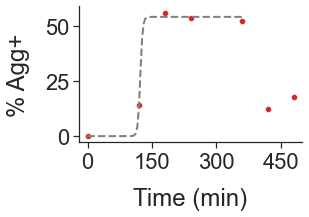

In [47]:
# sns.set(rc={"figure.figsize": (1.3, 2.5)})
sns.set(font_scale=2) 
sns.set_style("ticks")

plt.subplots(figsize = [4,2.5])

x = dep['deprivation_duration'][:5]
plot_x = np.linspace(x.min()-0.4, x.max(), 100)
plt.plot(plot_x, logistic(plot_x, *popt), 
         linewidth = 2,
         linestyle = 'dashed',
         color = 'gray')


g = sns.scatterplot(data=dep, x='deprivation_duration', y='percent', color = 'Tab:red')
sns.despine()
plt.ylabel("""% Agg+""",labelpad = 15)
plt.xlabel('Time (min)', labelpad=15)
g.xaxis.set_major_locator(plt.MaxNLocator(4))
plt.xlim(-20,500)
# plt.ylim(top=60)
# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Figure_1/linked_figure1/deprivation_time_refeed.pdf',
#             bbox_inches='tight', transparent=True)

In [11]:
df

,mice_ID,deprivation_duration,estrous_stage,state_before,retrieval_before_latency,state_before_comment,state_after,state_after_latency,parental_state_after,retrieval_after_latency,state_after_comment,exp_date
0,BRAC6691.6g,120,M,NaN,NaN,NaN,Agg-,NaN,NaN,NaN,NaN,NaN
1,BRAC6692.6i,120,P,NaN,NaN,NaN,Agg-,NaN,Parental+,NaN,NaN,NaN
2,BRAC7110.1h,120,M,NaN,NaN,NaN,Agg-,NaN,NaN,NaN,NaN,NaN
3,BRAC7110.1i,120,M,NaN,NaN,NaN,Agg-,NaN,NaN,NaN,NaN,NaN
4,BRAC7110.1j,120,M,NaN,NaN,NaN,Agg+,423.0,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
369,BRAC5370.6e,0,D,NaN,NaN,NaN,Agg-,NaN,NaN,NaN,NaN,NaN
370,BRAC5539.5g,0,D,NaN,NaN,NaN,Agg-,NaN,NaN,NaN,NaN,NaN
371,BRAC5539.5h,0,M,NaN,NaN,NaN,Agg-,NaN,NaN,NaN,NaN,NaN
372,BRAC5539.5i,0,D,NaN,NaN,NaN,Agg-,NaN,NaN,NaN,NaN,NaN


In [211]:
# number of mice in each duration category
unique_counts = df.groupby('deprivation_duration')['mice_ID'].nunique().reset_index()
unique_counts

,deprivation_duration,mice_ID
0,0,181
1,120,26
2,180,16
3,240,18
4,360,133


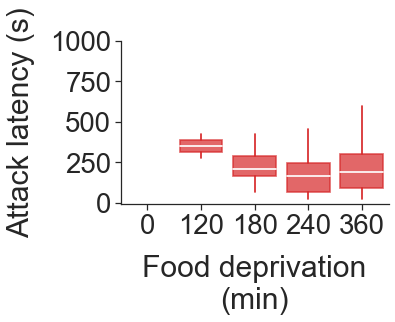

In [90]:
# plot the relationship between deprivation time and attack latency

sns.set(rc={"figure.figsize": (4.8, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

# at = sns.stripplot(x = 'deprivation_duration', y = 'state_after_latency', data = df, palette = ['gray'],alpha=.5, zorder=0, edgecolor='gray')
at = sns.boxplot(x = 'deprivation_duration', y = 'state_after_latency', data = df, whiskerprops=dict(color='tab:red'), medianprops={"color": "w"},
                 boxprops=dict(alpha=0.7,facecolor='tab:red', color='tab:red'), showfliers=False, linewidth=1.7, showcaps=False)

at.set_ylabel('Attack latency (s)', labelpad=15)
at.set_xlabel('Food deprivation\n(min)', labelpad=15)
at.yaxis.set_major_locator(plt.MaxNLocator(5))
plt.ylim(top=1000)
sns.despine()
plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_figure_1/linked figure_supplementary/deprivation_time_latency.pdf',
            dpi=600,bbox_inches='tight', transparent=False)

### stats for latency
model = smf.ols('state_after_latency ~ C(deprivation_duration)', data=df).fit()
sm.stats.anova_lm(model, typ=2)

In [14]:
# based on deprivation time, given that animal switch to be aggressive, what is the estrous cycle stage?
agg_df = df[df.state_after == 'Agg+']
estrous_dep = pd.crosstab(agg_df['deprivation_duration'], agg_df['estrous_stage'], margins = True).reset_index()
estrous_dep.iloc[:, 1:5] = estrous_dep.iloc[:, 1:5].div(estrous_dep.All, axis = 0) *100
estrous_dep = estrous_dep.iloc[:-1, :-1]
cols = ['deprivation_duration', 'P', 'E', 'M', 'D']
estrous_dep = estrous_dep[cols]

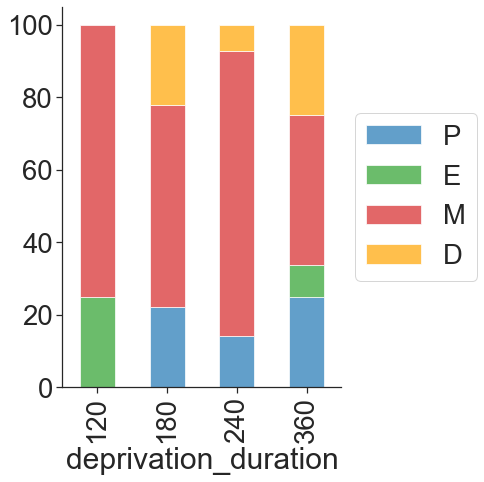

In [15]:
estrous_dep.plot(
          x = 'deprivation_duration', 
          kind = 'bar', 
          stacked = True,  
          mark_right = False,
          color = ['Tab:blue', 'Tab:green', 'Tab:red', 'orange'],
          figsize = (5,7), alpha = 0.7)

ax = plt.gca()
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
plt.savefig('output_figures/deprivation_time_hormone.jpeg', dpi = 300)

In [16]:
# how is switching probability differ in different estrous cyle per deprivation duration --> proportion plateau
df = pd.read_csv('deprivation_time.csv')
count = df.groupby(['deprivation_duration', 'estrous_stage'],dropna = False).size().unstack().fillna(0).stack().reset_index(name = 'count').dropna()
n = df.groupby(['deprivation_duration','estrous_stage', 'state_after'],dropna = False).size().unstack().fillna(0).stack().reset_index(name = 'n').dropna()
est_prop = count.merge(n, how = 'outer', on = ['deprivation_duration', 'estrous_stage'])
est_prop['percent'] = est_prop['n'] /est_prop['count'] *100
est_prop = est_prop.fillna(0)
est_prop['estrous_stage'] = pd.Categorical(est_prop['estrous_stage'], ['P', 'E', 'M', 'D'])
est_prop['deprivation_duration'] = pd.Categorical(est_prop['deprivation_duration'], [0,120, 180,240,360])

est_prop = est_prop.sort_values(by = ['deprivation_duration', 'estrous_stage'])

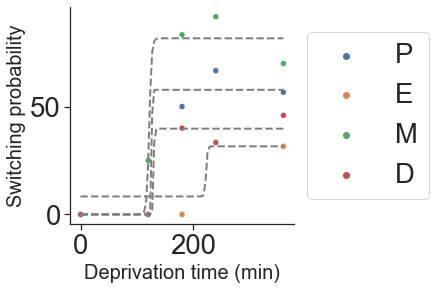

In [17]:
sns.scatterplot(data=est_prop[est_prop.state_after == 'Agg+'], x='deprivation_duration', y='percent', hue = 'estrous_stage',color = 'Tab:red')
As = {}
for stage in est_prop.estrous_stage.unique():
    fit_df = est_prop[(est_prop.state_after == 'Agg+') & (est_prop.estrous_stage == stage)]
    
    x = fit_df['deprivation_duration'].astype(np.float)
    y = fit_df['percent'].astype(np.float)
    
    try:
    #control for runtime error
        popt, pcov = curve_fit(logistic, x, y, p0=[50,185,0.1,0])
    except RuntimeError:
        continue
    As[stage] = popt[0]
    plot_x = np.linspace(x.min()-0.4, x.max(), 100)
    plt.plot(plot_x, logistic(plot_x, *popt), 
             linewidth = 2,
             linestyle = 'dashed',
             color = 'gray')
    plt.xlabel('Deprivation time (min)', fontsize = 20)
    plt.ylabel('Switching probability', fontsize = 20)
sns.despine()
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.savefig('output_figures/deprivation_time_hormone_SP.jpeg', dpi = 300)

# Environmental Factors for NPS Probability

In [18]:
bootstrap_sample = {}
sample = {}

for con in exp_conds:
    if con == 'food_deprivation':
        con_data = data[data['exp_cond'] == con][data['exp_time'] == 1][data['target'] == 'cricket']
        con_data = con_data[con_data['exp_time'] == 1]
        con_data_binary = np.where(con_data.state_after.values == 'Agg+', 1, 0)
        bootstrap_sample[con] = bootstrap(con_data_binary)
        sample[con] = [len(con_data[con_data.state_after =='Agg+']),
                      len(con_data[con_data.state_after =='Agg-'])]
    else:
        con_data = data[data['exp_cond'] == con][data['exp_time'] == 1][data['target'] == 'pup']
        con_data = con_data[con_data['exp_time'] == 1]
        con_data_binary = np.where(con_data.state_after.values == 'Agg+', 1, 0)
        bootstrap_sample[con] = bootstrap(con_data_binary)
        sample[con] = [len(con_data[con_data.state_after =='Agg+']),
                      len(con_data[con_data.state_after =='Agg-'])]

## stats comparing proportion of Agg+ mice experiencing different environmental conditions

In [19]:
itertool_stats(sample, 'fisher')

('all_stressor_5h', 'all_stressor_2h') 0.07907585751171708
('all_stressor_5h', 'food_deprivation') 1.0
('all_stressor_5h', 'water_deprivation') 0.009495955652908117
('all_stressor_5h', 'light_cycle_disturbed') 0.003015900956404384
('all_stressor_5h', 'novel_env') 0.0038949608743659063
('all_stressor_5h', 'all_stressor_plus_food') 0.009495955652908117
('all_stressor_2h', 'food_deprivation') 0.03347242787275091
('all_stressor_2h', 'water_deprivation') 1.0
('all_stressor_2h', 'light_cycle_disturbed') 0.4210526315789468
('all_stressor_2h', 'novel_env') 0.44444444444444486
('all_stressor_2h', 'all_stressor_plus_food') 1.0
('food_deprivation', 'water_deprivation') 0.00642853355196875
('food_deprivation', 'light_cycle_disturbed') 0.0010548481944362927
('food_deprivation', 'novel_env') 0.0025545325585707777
('food_deprivation', 'all_stressor_plus_food') 0.00642853355196875
('water_deprivation', 'light_cycle_disturbed') 1.0
('water_deprivation', 'novel_env') 1.0
('water_deprivation', 'all_stres

## visualization of environmental condition based probability of mice turning to be aggressive

In [20]:
# compute agg proportion for each condition
agg_plus_proportion = {}
agg_minus_proportion = {}
ns = {}

for con in exp_conds:
    if con == 'all_stressor_2h':
        pass
    elif con == 'food_deprivation':
        con_data = data[data['exp_cond'] == con][data['exp_time'] == 1][data['target'] == 'cricket']
        ns[con] = len(con_data)
        row_count = len(con_data)
        agg_count = len(con_data[con_data['state_after'] == 'Agg+']) 
        agg_plus_proportion[con] = agg_count / row_count * 100
        agg_minus_proportion[con] = 100 - agg_plus_proportion[con]
        
    else:
        con_data = data[data['exp_cond'] == con][data['exp_time'] == 1][data['target'] == 'pup']
        ns[con] = len(con_data)
        row_count = len(con_data)
        agg_count = len(con_data[con_data['state_after'] == 'Agg+']) 
        agg_plus_proportion[con] = agg_count / row_count * 100
        agg_minus_proportion[con] = 100 - agg_plus_proportion[con]

print(agg_plus_proportion)

{'all_stressor_5h': 56.25, 'food_deprivation': 62.5, 'water_deprivation': 0.0, 'light_cycle_disturbed': 0.0, 'novel_env': 0.0, 'all_stressor_plus_food': 0.0}


In [107]:
# add small constant value to zero entries to make column visible
for key, value in agg_plus_proportion.items():
    if value == 0:
        agg_plus_proportion[key] = 2

dict_values([56.25, 62.5, 2, 2, 2, 2])

In [112]:
agg_plus_proportion

{'all_stressor_5h': 56.25,
 'food_deprivation': 62.5,
 'water_deprivation': 2,
 'light_cycle_disturbed': 2,
 'novel_env': 2,
 'all_stressor_plus_food': 2}

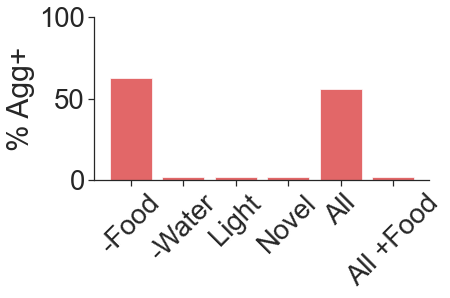

In [120]:
sns.set(rc={"figure.figsize": (6, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

# i = 0
# for position in agg_plus:
#     plt.text(position.get_x() + position.get_width()/2., 1.05 * position.get_height(),
#             'n = ' + str(list(ns.values())[i]) ,ha='center', va='bottom', fontsize = 28)
#     i += 1

order = ['food_deprivation', 'water_deprivation', 'light_cycle_disturbed', 'novel_env', 'all_stressor_5h', 'all_stressor_plus_food']
values = [agg_plus_proportion[key] for key in order]
plt.bar(range(len(values)), values, tick_label=order, align='center', color='tab:red', alpha=0.7)
plt.xlabel(None)
plt.ylabel('% Agg+')
    
locs, labels = plt.xticks()
plt.xticks(locs, ['-Food', '-Water', 'Light', 'Novel', 'All', 'All +Food'])
plt.xticks(rotation = 45)
plt.ylim(0, 100)
sns.despine()

plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_figure_1/linked figure_supplementary/hunger.pdf',
            dpi=600,bbox_inches='tight', transparent=True)

# the effect of spontaneous state on NPS

## compute the probability of Agg+ mice depending on the spontaneous parental state

In [22]:
tar_data = data[data.target.isin(['pup', 'maze', 'intruder', 'cricket', 'cfos', 'refeeding_1h', 'refeeding_2h', 'openfield'])]
agg_cond_data = pd.concat([tar_data[tar_data['exp_cond'] == agg_conds[0]], 
                    tar_data[tar_data['exp_cond'] == agg_conds[1]]])
agg_cond_data_first = agg_cond_data[agg_cond_data['exp_time'] == 1]

con_spon_ig, n_ig = compute_conditional(agg_cond_data_first, 'Agg+','state_after', 'Parental-','state_before')
con_spon_parental, n_parental = compute_conditional(agg_cond_data_first, 'Agg+','state_after','Parental+','state_before')
n = [n_ig, n_parental]
print(n)
print(con_spon_ig, con_spon_parental)

[67, 66]
0.5671641791044776 0.48484848484848486


In [23]:
# stats to see whether the spontaneous state differentially affect the likelihood of being aggressive
spon_df = agg_cond_data_first.copy()
spon_df.loc[spon_df.state_after == 'Agg-', 'state_after'] = spon_df.loc[spon_df.state_after == 'Agg-', 'parental_state_after']
spon_table = pd.crosstab(spon_df.state_before, spon_df.state_after)
spon_chi, spon_p, dof, expected = stats.chi2_contingency(spon_table)
spon_table = spon_table.reset_index()
print(spon_table)
print(spon_p)

state_after state_before  Agg+  Parental+  Parental-
0              Parental+    32         30          4
1              Parental-    38          9         18
3.160100919462887e-05


In [24]:
spon_table

state_after,state_before,Agg+,Parental+,Parental-
0,Parental+,32,30,4
1,Parental-,38,9,18


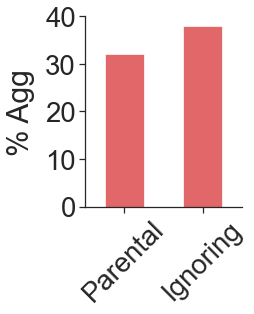

In [111]:
sns.set(rc={"figure.figsize": (2.8, 3.5)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

spon = spon_table.plot(
          x = 'state_before',
          y = 'Agg+',  
          kind = 'bar', 
          color = ['Tab:red', 'Tab:red'],
          alpha = 0.7)
spon.set_xticklabels( ('Parental', 'Ignoring'), rotation=45)
plt.ylabel('% Agg', labelpad=10)
spon.set_xlabel('')
plt.ylim(top=40)
spon.yaxis.set_major_locator(plt.MaxNLocator(4))
spon.legend_.remove()
sns.despine()

plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_figure_1/linked figure_supplementary/spontaneous_state.pdf',
            dpi=600,bbox_inches='tight', transparent=True)

# Estrous stages and NPS Probability

## impact of estrous cycle on the proportion of spontaneous parental and ignoring mice

In [26]:
est_spon_ig = {}
est_spon_parental = {}
n_spon_ig = {}
n_spon_parental = {}

data_est = tar_data[tar_data['exp_time'] == 1]

for estrous_stage in estrous_stages:
    est_data = data_est[data_est['estrous_stage'] == estrous_stage]
    est_data = est_data[est_data['exp_time'] == 1]
    est_spon_ig_data = est_data[est_data['state_before'] == 'Parental-']
    est_spon_parental_data = est_data[est_data['state_before'] == 'Parental+']
    est_spon_ig[estrous_stage] = len(est_spon_ig_data) / len(est_data)
    n_spon_ig[estrous_stage] = len(est_spon_ig_data)
    est_spon_parental[estrous_stage] = len(est_spon_parental_data) / len(est_data)
    n_spon_parental[estrous_stage] = len(est_spon_parental_data)
    

## plot proportion of mice being spontaneous parental or ignoring under different estrous cycle stage

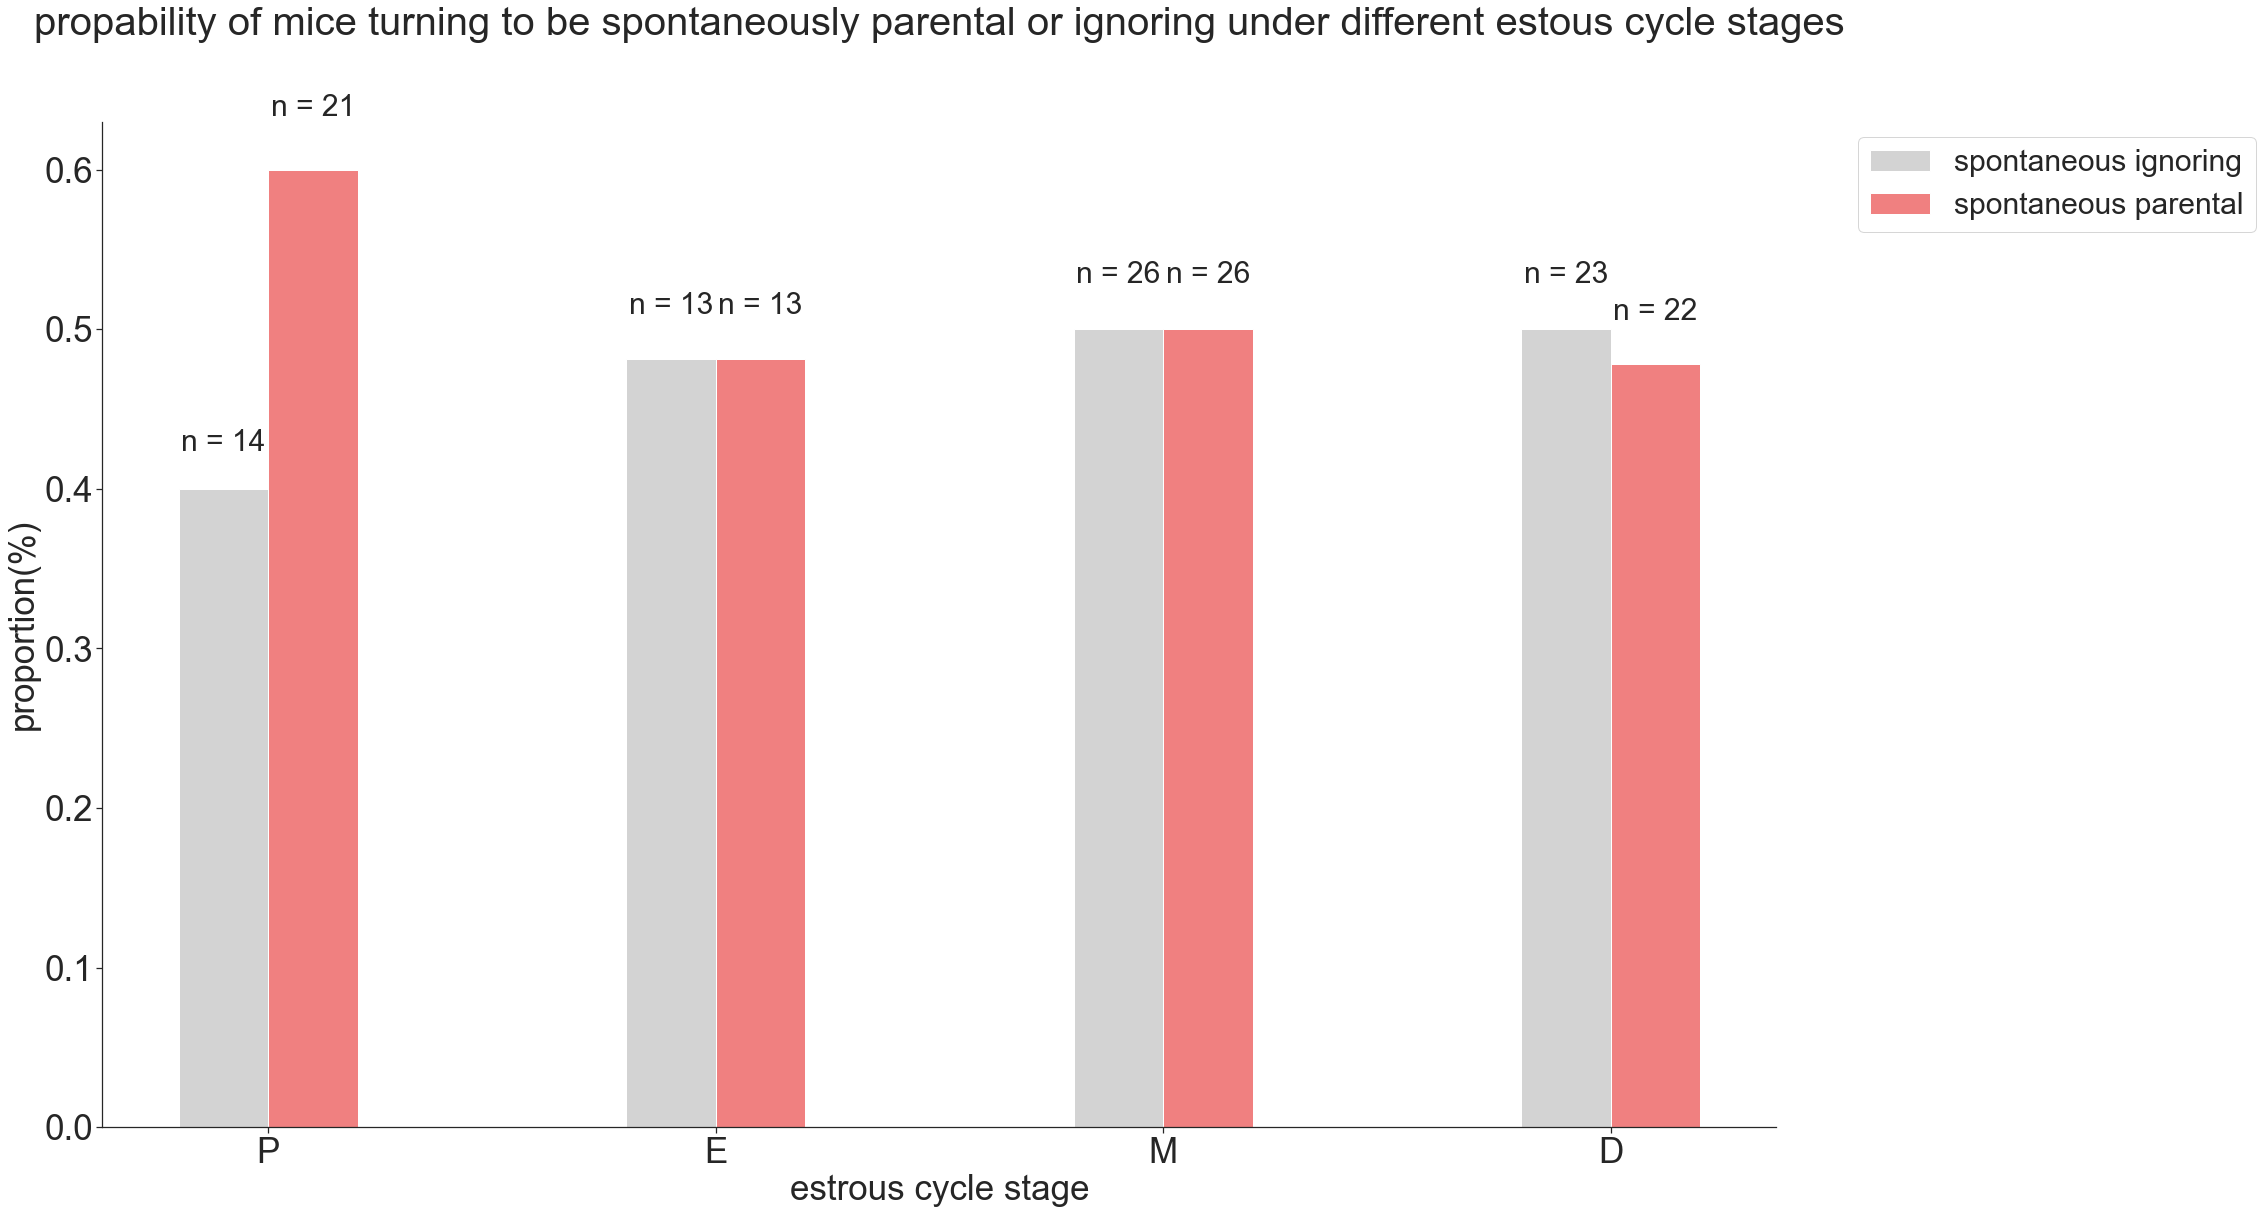

In [27]:
fig, ax = plt.subplots(figsize = (30, 18.5))
plt.rcParams['axes.facecolor'] = 'white'
w = 0.1
x = np.arange(len(est_spon_parental))

est_spon_ig_fig = ax.bar(x - w, list(est_spon_ig.values()),
                        align = 'center', color = 'lightgray', width = 0.2)
i = 0
for position in est_spon_ig_fig:
    plt.text(position.get_x() + position.get_width()/2., 1.05 * position.get_height(),
            'n = ' + str(list(n_spon_ig.values())[i]) ,ha='center', va='bottom', fontsize = 30)
    i += 1

    
est_spon_parental_fig = ax.bar(x + w, list(est_spon_parental.values()),
                            align = 'center', 
                            color = 'lightcoral', width = 0.2)
i = 0
for position in est_spon_parental_fig:
    plt.text(position.get_x() + position.get_width()/2., 1.05 * position.get_height(),
            'n = ' + str(list(n_spon_parental.values())[i]) ,ha='center', va='bottom', fontsize = 30)
    i += 1
    
    
ax.legend(['spontaneous ignoring', 'spontaneous parental'], bbox_to_anchor = (1.04, 1), 
           loc = 'upper left', fontsize = 30)
ax.set_xlabel('estrous cycle stage', fontsize = 35)
ax.set_ylabel('proportion(%)', fontsize = 35)
ax.set_title('propability of mice turning to be spontaneously parental or ignoring under different estous cycle stages',
         fontsize = 40, y = 1.08)

ax.set_xticks(x)
ax.set_xticklabels(list(est_spon_ig.keys()),fontsize = 35)  
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.tick_params(axis="y", labelsize = 35)

plt.show()

## impact of estrous cycle on the proportion of mice turning to be aggressive

In [28]:
estrous_data = {}
ns = {}
ns_spon_ig = {}
ns_spon_parental = {}
agg_latency = {}
est_con_spon_ig = {}
est_con_spon_parental = {}
len_agg = {}


for estrous_stage in estrous_stages:
    # proportion of mice turning to be aggressive at different estrous cycle stage
    est_data = agg_cond_data_first[agg_cond_data_first['estrous_stage'] == estrous_stage]
    est_data_agg = est_data[est_data['state_after'] == 'Agg+']
    union_p = est_data_agg[est_data_agg['state_before'] =='Parental+']
    union_m = est_data_agg[est_data_agg['state_before'] =='Parental-']
    
    len_agg[estrous_stage] = len(est_data_agg)
    est_data_agg_latency = est_data_agg['state_after_latency']
    est_prop = len(est_data_agg) / len(est_data) * 100
    estrous_data[estrous_stage] = est_prop
    ns[estrous_stage] = len(est_data)
    agg_latency[estrous_stage] = est_data_agg_latency
    
    # conditional propability of mice turning to be aggressivce at different estrous cycle stage
    est_con_spon_ig[estrous_stage] = compute_conditional(est_data, 'Agg+','state_after', 'Parental-', 'state_before')[0]
    ns_spon_ig[estrous_stage] = len(est_data[est_data['state_before'] == 'Parental-'])
    est_con_spon_parental[estrous_stage] = compute_conditional(est_data, 'Agg+','state_after', 'Parental+','state_before')[0]
    ns_spon_parental[estrous_stage] = len(est_data[est_data['state_before'] == 'Parental+'])

print(estrous_data)
print(est_con_spon_ig)
print(est_con_spon_parental) 
print(ns) 
# estrous_data = pd.DataFrame.from_dict(estrous_data, orient = 'index')
# estrous_data.to_csv('generated_datasets/estrous_data.csv')

{'P': 56.666666666666664, 'E': 31.57894736842105, 'M': 70.0, 'D': 45.94594594594595}
{'P': 0.6923076923076923, 'E': 0.6, 'M': 0.6818181818181818, 'D': 0.42105263157894735}
{'P': 0.47058823529411764, 'E': 0.0, 'M': 0.7222222222222222, 'D': 0.5}
{'P': 30, 'E': 19, 'M': 40, 'D': 37}


## infer statistical power

In [29]:
for subset in itertools.combinations(estrous_data.keys(), 2):
    stat, p, dof, expected  = stats.chi2_contingency([[len_agg[subset[0]], ns[subset[0]] - len_agg[subset[0]]],
                                        [len_agg[subset[1]], ns[subset[1]] - len_agg[subset[1]]]])
    print(subset, p)

('P', 'E') 0.1553792659131704
('P', 'M') 0.36806550630548474
('P', 'D') 0.530585360727371
('E', 'M') 0.012119552049891789
('E', 'D') 0.454546665752126
('M', 'D') 0.05633523486814524


## plot proportion turning to be aggressive vs estrous stages

{'P': 56.666666666666664, 'E': 31.57894736842105, 'M': 70.0, 'D': 45.94594594594595}


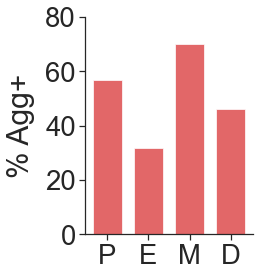

In [30]:
sns.set(font_scale=2.5)
sns.set_style("ticks")

fig, ax = plt.subplots(figsize = (3, 4))

print(estrous_data)
fig = plt.bar(range(len(estrous_data)), list(estrous_data.values()),
        tick_label = list(estrous_data), align = 'center', 
        color = 'Tab:red', width = 0.7, alpha = 0.7)

plt.xlabel('')
plt.ylabel('% Agg+', labelpad=10)

# i = 0
# for position in fig:
#     plt.text(position.get_x() + position.get_width()/2., 1.05 * position.get_height(),
#             'n = ' + str(list(ns.values())[i]) ,ha='center', va='bottom', fontsize = 15)
#     i += 1

# ax.spines['right'].set_visible(False)
# ax.spines['top'].set_visible(False)
ax.yaxis.set_major_locator(plt.MaxNLocator(4))
plt.ylim(0, 80)
# ax.tick_params(bottom=False)
sns.despine(bottom=False, trim=False)

plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Figure_4/linked_figure4/estrous_cycle.pdf',dpi=300,bbox_inches='tight')

## plot conditional probability of mice turning to be aggressivce 

In [31]:
for stage in estrous_stages:
    est_data = agg_cond_data_first[agg_cond_data_first['estrous_stage'] == stage]
    tab = pd.crosstab(est_data.state_before, est_data.state_after)
    odds, p  = stats.fisher_exact(tab)
    print(stage, p)

P 0.282756666779392
E 0.010835913312693502
M 1.0
D 0.7458545854734879


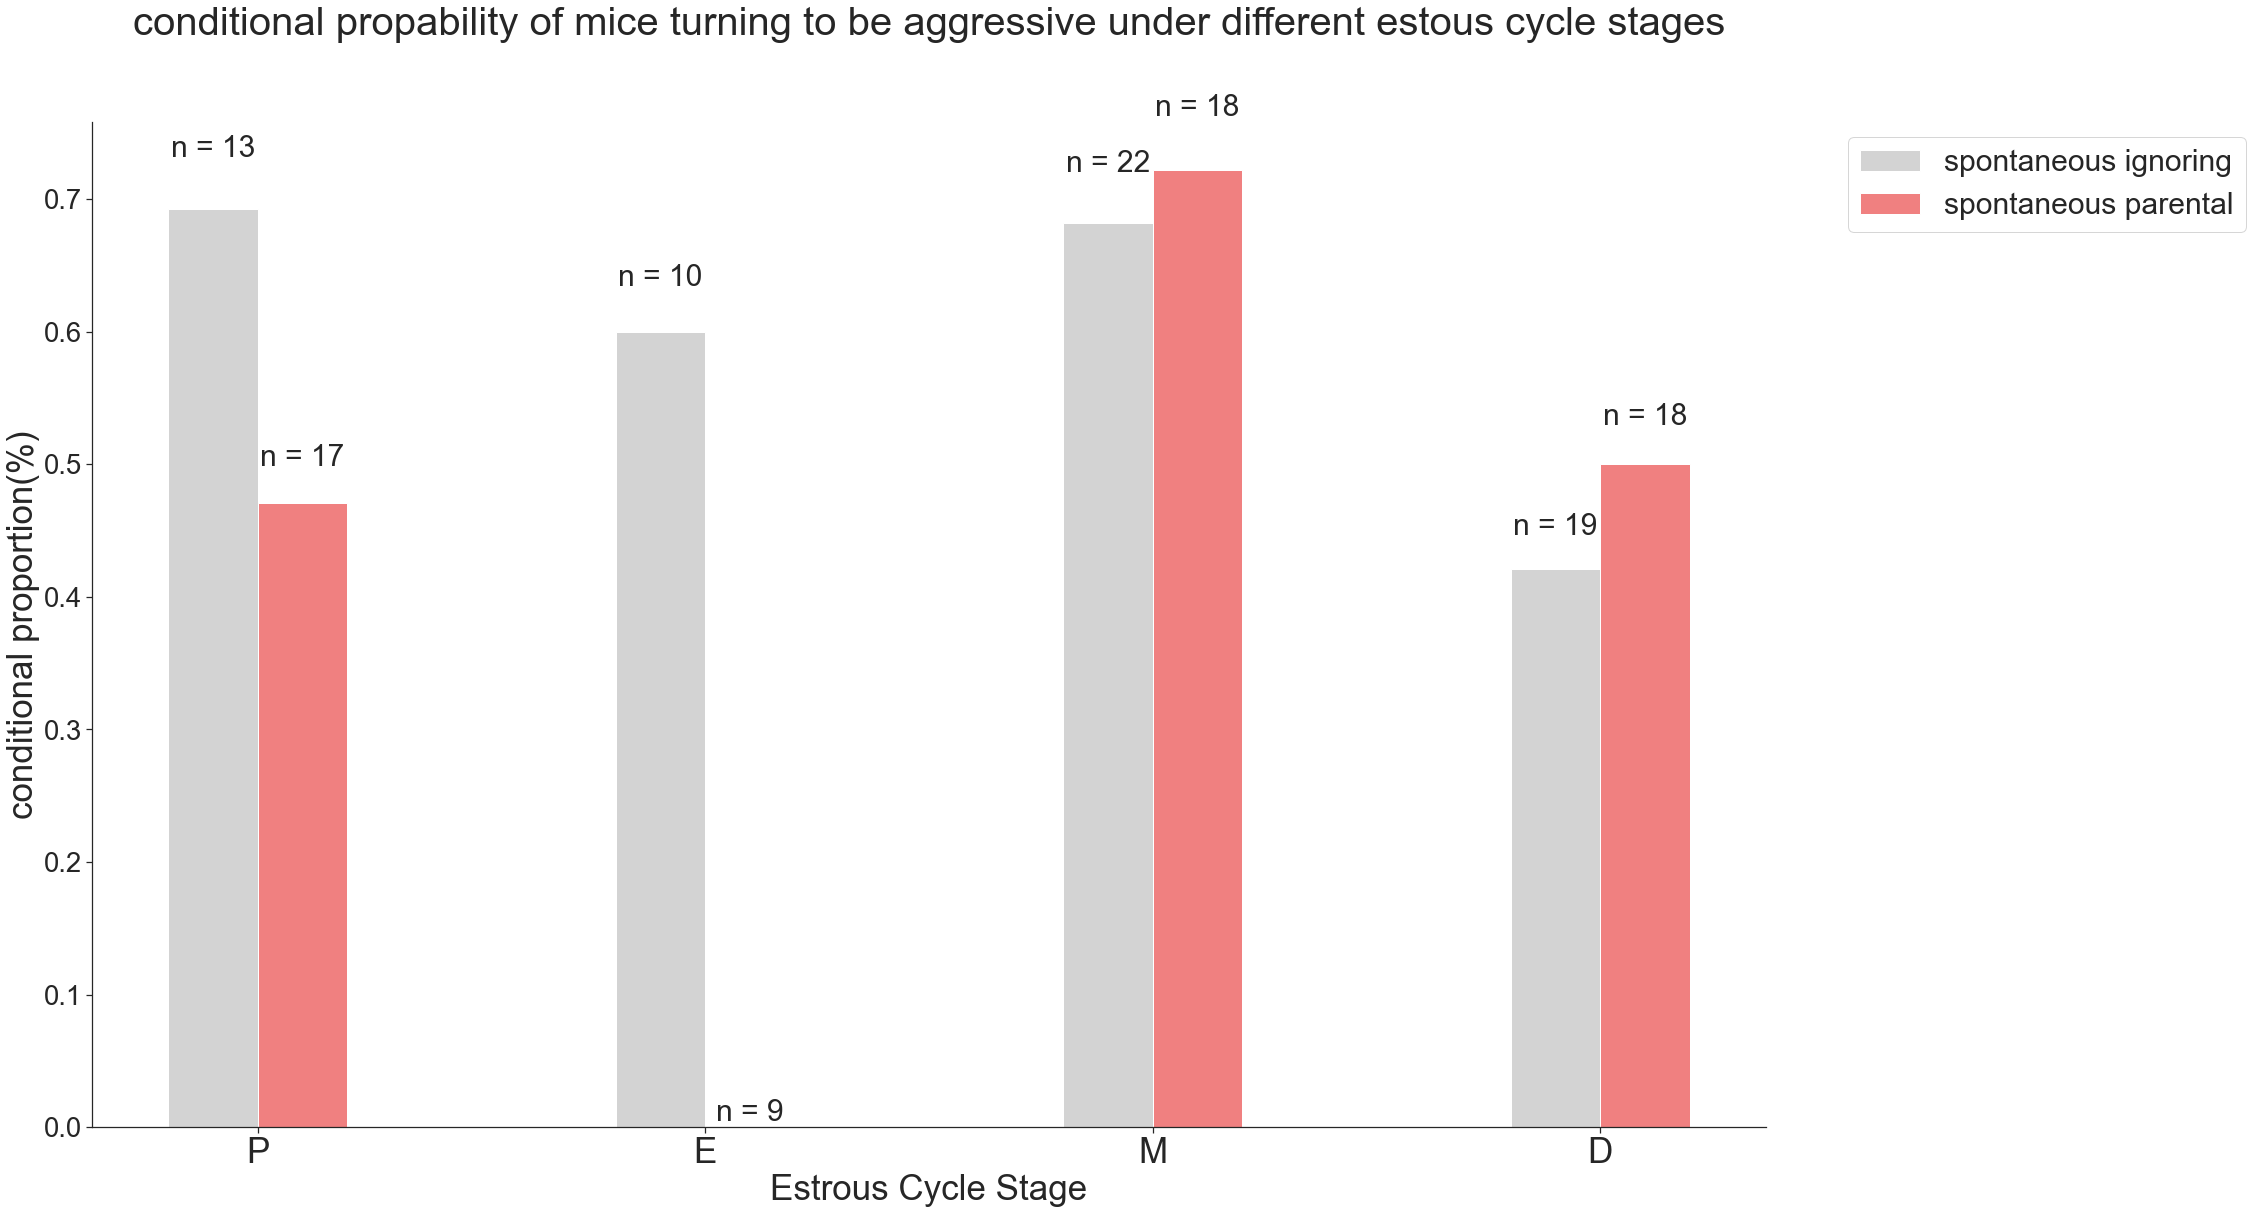

In [32]:
fig, ax = plt.subplots(figsize = (30, 18.5))
plt.rcParams['axes.facecolor'] = 'white'
w = 0.1
x = np.arange(len(est_con_spon_parental))

est_con_spon_ig_fig = ax.bar(x - w, list(est_con_spon_ig.values()),
                              align = 'center', color = 'lightgray', width = 0.2)
i = 0
for position in est_con_spon_ig_fig:
    plt.text(position.get_x() + position.get_width()/2., 1.05 * position.get_height(),
            'n = ' + str(list(ns_spon_ig.values())[i]) ,ha='center', va='bottom', fontsize = 30)
    i += 1

    
est_con_spon_parental_fig = ax.bar(x + w, list(est_con_spon_parental.values()),
                            align = 'center', color = 'lightcoral', width = 0.2)
i = 0
for position in est_con_spon_parental_fig:
    plt.text(position.get_x() + position.get_width()/2., 1.05 * position.get_height(),
            'n = ' + str(list(ns_spon_parental.values())[i]) ,ha='center', va='bottom', fontsize = 30)
    i += 1
    
    
ax.legend(['spontaneous ignoring', 'spontaneous parental'], bbox_to_anchor = (1.04, 1), 
           loc = 'upper left', fontsize = 30)
ax.set_xlabel('Estrous Cycle Stage', fontsize = 35)
ax.set_ylabel('conditional proportion(%)', fontsize = 35)
ax.set_title('conditional propability of mice turning to be aggressive under different estous cycle stages',
         fontsize = 40, y = 1.08)

ax.set_xticks(x)
ax.set_xticklabels(list(est_con_spon_ig.keys()),fontsize = 35)
#ax.set_yticklabels([0.0, 0.2, 0.4, 0.6, 0.8, 1.0],fontsize = 35)  
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
plt.savefig('output_figures/spontaneous_estrous_state.jpg', dpi = 300, bbox_inches='tight')
plt.show()

## plot aggression latency vs estrous stages

In [33]:
tab_agg_latency = {}
for i in estrous_stages:
    tab_agg_latency[i] = agg_cond_data_first[agg_cond_data_first['estrous_stage'] == i]['state_after_latency'].dropna()

itertool_stats(tab_agg_latency, 'ttest')

('P', 'E') 0.6630991803989916
('P', 'M') 0.6573909173169192
('P', 'D') 0.5017855340552402
('E', 'M') 0.8035990614731735
('E', 'D') 0.9161957718691655
('M', 'D') 0.7693419187299396


(array([0, 1, 2, 3]),
 [Text(0, 0, 'P'), Text(1, 0, 'E'), Text(2, 0, 'M'), Text(3, 0, 'D')])

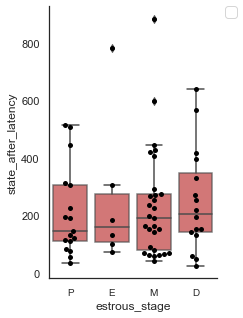

In [34]:
sns.set(rc={'figure.figsize':(3,5)})
sns.set_style("white")
ax = category_plotting('estrous_stage', 
                  'state_after_latency',
                  None, 
                  agg_cond_data_first, 
                  estrous_stages)

plt.xticks(fontsize = 10)
# plt.savefig('output_figures/estrous_latency.jpg', dpi = 300, bbox_inch = 'tight')

## plot aggression latency versus spontaneous parental & ignoring

(array([0, 1, 2, 3]),
 [Text(0, 0, 'P'), Text(1, 0, 'E'), Text(2, 0, 'M'), Text(3, 0, 'D')])

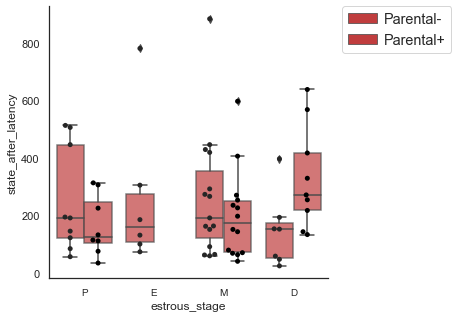

In [35]:
sns.set(rc={'figure.figsize':(5,5)})
sns.set_style("white")
ax = category_plotting('estrous_stage', 
                  'state_after_latency',
                  'state_before', 
                  agg_cond_data_first, 
                  estrous_stages)
plt.xticks(fontsize = 10)

# Relationship between P/E level and swiching probability 

## fit a function to the P/E curve

In [36]:
from scipy.optimize import curve_fit
from scipy.special import logit

# define function to be fitted 
def func(x, a,b,c,d):
    return a* np.log(b*x/(1-x)+c)+d

def logit_fitting(df, column):
    x = df['P/E* 10^-3'] 
    y = df[column] 
    popt, pcov = curve_fit(func, x, y)

    # calculate the R2 score to evaluate the goodness of curve fitting
    residuals = y- func(x, popt)  #*popt
    ss_res = np.sum(residuals**2)
    # ss_tot = np.sum((y-np.mean(y))**2)
    r_squared = 1 - (ss_res / ss_tot)
    print(r_squared)
    print(popt) #*popt
    
    return x,popt #*popt

In [37]:
## temporary cells for tracing the effect of hormone on switching rate over time
hormone = pd.read_csv('hormone_level/hormone.csv')

columns = estrous_dep.T.reset_index().iloc[0][1:]
hormone_df = estrous_dep.T.iloc[1:,:]
hormone_df.columns = columns
hormone_df = hormone_df.reset_index()
hormone_df.rename(columns = {'estrous_stage':'stage'}, inplace = True)
hormone_df = pd.merge(hormone_df, hormone)
hormone_df['P/E* 10^-3'] = hormone_df['P/E* 10^-3']*0.1

for time in columns.unique()[:]:
    
    hormone_df[time] = hormone_df[time] *0.01

    try:
        print('fitting for deprivation time ' + str(time))
        x, *popt = logit_fitting(hormone_df, time)
        
        fig, ax = plt.subplots(figsize = (6,3))
        sns.scatterplot(data=hormone_df, x='P/E* 10^-3', y=time, 
                        hue = 'stage', palette = ['darkblue', 'dodgerblue', 'skyblue', 'lightskyblue'])

        plot_x = np.linspace(x.min(), x.max(), 100)
        plt.plot(plot_x, func(plot_x, *popt), 
                 linewidth = 2,
                 linestyle = 'dashed',
                 color = 'gray')
        plt.xscale("log")
        # plt.ylim([0,1])
        # plt.xlim([0.05,1])

        sns.despine()
        
    except RuntimeError:
        print('fitting not successful for time ' + str(time))
        
        

fitting for deprivation time 120
fitting not successful for time 120
fitting for deprivation time 180


TypeError: func() missing 3 required positional arguments: 'b', 'c', and 'd'

In [ ]:
logistic = pd.DataFrame(As, index = [0]).T.reset_index()
logistic.rename(columns = {0:'A', 'index':'stage'}, inplace = True)
logistic = pd.merge(logistic, hormone_df, on = ['stage'])

sns.scatterplot(data=logistic, x='P/E* 10^-3', y='A', 
                        hue = 'stage', palette = ['darkblue', 'dodgerblue', 'skyblue'])
plt.xscale("log")
# plt.xlim([0.05,1])

sns.despine()
plt.legend( bbox_to_anchor = (1.04, 1), loc = 'upper left', fontsize = 15)

In [ ]:
# initialise dataframe
# hormone['P/E'] = hormone['max_estrogen_level(pg/ml)']/hormone['end_dark_phase_progesterone(ng/ml)'] 
hormone['switching probability'] = hormone['switching probability'] *0.01
hormone['P/E* 10^-3'] = hormone['P/E* 10^-3']*0.1
# set up hormone state to include
preg = hormone[hormone.stage.isin(['PD10', 'PD18'])]
hormone = hormone[hormone.stage.isin(['P', 'E', 'M', 'D'])]

# curve fitting
x = hormone['P/E* 10^-3']
y = hormone['switching probability']
popt, pcov = curve_fit(func, x, y)

# calculate the R2 score to evaluate the goodness of curve fitting
residuals = y- func(x, *popt)
ss_res = np.sum(residuals**2)
# ss_tot = np.sum((y-np.mean(y))**2)
r_squared = 1 - (ss_res / ss_tot)
print(r_squared)
print(*popt)

In [ ]:
hormone

In [ ]:
sns.set(rc={"figure.figsize": (4, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

g = sns.scatterplot(data=hormone, x='P/E* 10^-3', y='switching probability', s=60,
                hue = 'stage', palette = ['Tab:red', 'Tab:red', 'Tab:red', 'Tab:red'])

plot_x = np.linspace(0, 1, 100)
plt.plot(plot_x, func(plot_x, *popt), 
         linewidth = 2,
         linestyle = 'dashed',
         color = 'gray')

plt.xscale("log")
plt.xticks()
plt.yticks()
plt.ylim([0,1])

g.set_xlabel('P4 / E2 (× $10^{-2}$)', labelpad=10) #(P4 / E2) × $10^{-2}$
g.set_ylabel('$P_{S}$', labelpad=10)

g.get_legend().set_visible(False)
sns.despine()

# plt.savefig('/Users/kohlj/Downloads/hormone_ratio.pdf',dpi=600,bbox_inches='tight')
# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Figure_4/linked_figure4/hormone_ratio.pdf',dpi=600,bbox_inches='tight')# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Figure_4/linked_figure4/hormone_ratio.pdf',dpi=600,bbox_inches='tight')

In [ ]:
plt.subplots(figsize = (1.7,3.5))
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.barplot(x = 'stage', y = 'switching probability', data = preg, palette = ['red', 'red'], alpha = 0.7)

i = 0
for stage in preg.stage.unique():
    v = preg[preg.stage == stage]['P/E* 10^-3'].values
    z = func(v[0], *popt)
    plt.hlines(y = z, xmin = i-0.5, xmax = i+ 0.5, linestyle = 'dashed', color = 'black', lw=3)
    i += 1
plt.xticks(rotation=45)
plt.yticks()
plt.ylabel('$P_{S}$', labelpad=10)
plt.xlabel('')
ax.set_xticklabels( ('D10', 'D18'), rotation=45)
plt.ylim([0,1])
sns.despine(bottom=False)
# ax.tick_params(bottom=False)

plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Figure_4/linked_figure4/preg_switching_prediction.pdf',dpi=600,bbox_inches='tight')

## Receptor expression in MPOA and Arcuate 

In [ ]:
import pathlib
path = '/receptor_level/'

df1 = pd.read_csv(str(pathlib.Path().resolve()) + path+'df_166-3.csv')
df2 = pd.read_csv(str(pathlib.Path().resolve()) + path+'df_167-3.csv')

df = pd.concat([df1,df2])
average = df[['% Esr1','% PR']].mean()


df = df[df['Unnamed: 0'].isin(['MPO', 'MPN','PD', 'ADP','PS', 'ARH'])]

df = df.replace({'Unnamed: 0':{'ARH':'ARC'}})
df.loc['mean'] = df[df['Unnamed: 0'].isin(['MPO', 'MPN','PD', 'ADP','PS'])].mean()
df = df.replace({'Unnamed: 0':{np.nan:'MPOA'}})

In [ ]:
fig = plt.figure(figsize = (6,6))
sns.set(font_scale=1.8)
sns.set_style("white")
ax1 = fig.add_subplot(131)

g = sns.barplot(x = 'Unnamed: 0', 
            y = '% Esr1',
            data = df[df['Unnamed: 0'].isin(['MPOA', 'ARC'])],
            alpha=.5, 
            palette=["lightblue"])

g.axhline(average['% Esr1'], 
          color = 'deepskyblue',
          linewidth=2,
          linestyle = 'dashed')

plt.ylim([0,100])
plt.title('%ESR1')
ax1.set_xlabel('')
ax1.set_ylabel('Proportion of neurons \nexpressing receptor transcript (%)',fontsize = 25)
sns.despine()
plt.xticks(rotation=45)

ax2 = plt.subplot(133)

g2 =sns.barplot(x = 'Unnamed: 0', 
            y = '% PR',
            data = df[df['Unnamed: 0'].isin(['MPOA', 'ARC'])],
            alpha=0.3, 
            palette=["purple"])

g2.axhline(average['% PR'], 
           color = 'purple',
           linewidth=2,
           linestyle = 'dashed')

plt.ylim([0,100])
ax2.set_xlabel('')
ax2.set_ylabel('Proportion of neurons \nexpressing receptor transcript (%)',fontsize = 25)

plt.title('%PR')
sns.despine()
plt.xticks(rotation=45)
plt.savefig('output_figures/receptor_proportion', dpi = 300)

# Pregnancy stage and NPS probability

initialize pregnancy stages and extract data

pre state analysis

In [ ]:
preg_stages_pre = ['PD2', 'PD2_pre', 'PD10', 'PD18']
preg_stages = ['PD2','PD10', 'PD18']
preg_data = data[data.target.isin(preg_stages)]

In [ ]:
preg_data_pre = data[data.target.isin(preg_stages_pre)]
preg_data_pre = preg_data_pre.replace('PD2_pre', 'PD2')
preg_data_pre_count = preg_data_pre.groupby(['target']).size().reset_index(name='count')
preg_data_pre = preg_data_pre.groupby(['state_before','target']).size().reset_index(name = 'n')
preg_data_pre = preg_data_pre.merge(preg_data_pre_count, how = 'outer', on = 'target')
preg_data_pre['percent'] = preg_data_pre['n'] / preg_data_pre['count']
preg_data_pre['target'] = pd.Categorical(preg_data_pre['target'], ['PD2', 'PD10', 'PD18'])

preg_data_pre = preg_data_pre.sort_values(by = ['target'])
print(preg_data_pre)

In [ ]:
sns.set(rc={'figure.figsize':(7,5)})
sns.set_style("white")
g = sns.catplot(x = 'target', 
                y = 'percent', 
                hue = 'state_before', 
                kind = 'bar', 
                data = preg_data_pre,
                palette = ['royalblue', 'gainsboro'])
g.set(xlabel = 'Pregnancy Stages')

In [ ]:
ret_per = preg_data.groupby('target')['retrieval_before_latency'].apply(lambda x: x.notnull().mean()).reset_index(name = 'percentage')

sns.set(rc={'figure.figsize':(5,5)})
sns.set_style("white")
g = sns.catplot(x = 'target', 
                y = 'percentage',
                kind = 'bar', 
                data = ret_per,
                order = preg_stages,
                palette = ['royalblue'])

post state analysis

In [ ]:
preg_data_post_count = preg_data.groupby(['target']).size().reset_index(name='count')
preg_data_post = preg_data.groupby(['state_after','target']).size().reset_index(name = 'n')
preg_data_post = preg_data_post.merge(preg_data_post_count, how = 'outer', on = 'target')
preg_data_post['percent'] = preg_data_post['n'] / preg_data_post['count']
preg_data_post['target'] = pd.Categorical(preg_data_post['target'], ['PD2', 'PD10', 'PD18'])

preg_data_post = preg_data_post.sort_values(by = ['target'])
print(preg_data_post)

In [ ]:
preg_hor = pd.concat([hormone,preg])
preg_hor = preg_hor.set_index('stage')
preg_hor = preg_hor.loc[[ 'PD10', 'PD18']]

In [ ]:
sns.set(font_scale=1.2)
sns.set_style("white")
g = sns.catplot(x = 'target', 
                y = 'percent', 
                hue = 'state_after', 
                kind = 'bar', 
                data = preg_data_post,
                palette = ['red', 'gainsboro'],
                aspect = 20/15, alpha = 0.7)
g.set(xlabel = 'Pregnancy Stages')

ax = plt.gca()
ax.set_ylabel('Proportion of mice switched (%)')
ax2 = ax.twinx()
ax2.set_ylabel('Progesterone / estrodiol ratio *10^-3')
ax2.plot([ 'PD10', 'PD18'], preg_hor['P/E* 10^-3'], color = 'r', linewidth = 2)

ax2.legend(loc='center right', bbox_to_anchor=(1.35, 0.5), ncol=1)
ax2.set_ylim([0,9])
preg_n = preg_data_post.sort_values(by = ['state_after'])
autolabel(g, preg_n['n'].tolist())
sns.despine(top = True, right = False)

In [ ]:
preg_cond_ig = {}
preg_cond_parental = {}

preg_data = data[data.target.isin(['PD2', 'PD10', 'PD18'])]

for preg_stage in preg_stages:
    preg_stage_data = preg_data[preg_data['target'] == preg_stage]
    preg_cond_ig[preg_stage], _ = compute_conditional(preg_stage_data, 'Agg+','state_after', 'Parental-','state_before')
    preg_cond_parental[preg_stage], _ = compute_conditional(preg_stage_data, 'Agg+','state_after','Parental+','state_before')

print(preg_cond_ig)
print(preg_cond_parental)

# Receptor KO and NPS

In [ ]:
from scipy.stats import binom
from poibin import PoiBin

def binomial_range(data, estrous_data):
    ps = []
    
    for i in data['estrous_stage'].unique():
        n = int(data[data['estrous_stage'] == i]['estrous_count'].iloc[0])
        p = estrous_data[i] *0.01
        p = [p] * n
        
        ps.extend(p)
    
    # produce and return a poisson binomial pmf based on list of means from estrous cycle stages
    pb = PoiBin(ps)
    x = np.arange(0, int(data['estrous_count'].sum()/2))
    dist = pb.cdf(x)
    pmf = pb.pmf(x)

    # get mean of the distibution
    mean = int(np.where(pmf == pmf.max())[0]) # most probable value
    std = np.sqrt(np.sum([i*j for i, j in zip([1-p for p in ps] ,ps)]))
    mean_t  = np.sum(ps) # mean of the distribution
    
    # get the 0.05 interval 
    lower = mean_t - 2* std
    #lower = np.where(dist > 0.05)[0][0] # using distribution
    
    # get the 0.95 confidence interval
    higher = mean_t + 2 * std
    #higher = np.where(dist < 0.95)[0][-1] # using distribution
    
    
    return lower, higher, mean, pb
       

In [ ]:
KO_dat = pd.read_csv('../NPW_hormone/receptor_KO/receptorKO.csv')

viruses = ['EGFP-CRE', 'EGFP']
areas = ['MPOA', 'ARC']
receptors = ['PR', 'ESR']

KO_dat = KO_dat[(KO_dat.injection_site.isin(areas)) &
                (KO_dat.validation != 'invalid')&
                (KO_dat.state_after!= 'invalid')]

KO_count = KO_dat.groupby(['KO', 'injection_site', 'virus', 'state_after']).size().reset_index(name='count')
KO_n = KO_dat.groupby(['KO','injection_site', 'virus']).size().reset_index(name = 'n')
KO_count = KO_count[KO_count.virus == 'EGFP-CRE']
KO_n = KO_n[KO_n.virus == 'EGFP-CRE']

c_count = KO_dat.groupby(['injection_site', 'virus', 'state_after']).size().reset_index(name='count')
c_n = KO_dat.groupby(['injection_site', 'virus']).size().reset_index(name = 'n')
c_count = c_count[c_count.virus == 'EGFP']
c_n = c_n[c_n.virus == 'EGFP']

KO_n = pd.concat([KO_n,c_n])
KO_count = pd.concat([KO_count, c_count])

In [ ]:
# calculate predicted probability of switching based on the number of animals in different estrous cycle stages

KO_df = KO_n.merge(KO_count, how = 'outer', on = ['KO', 'injection_site', 'virus'])
KO_df['percent'] = KO_df['count'] / KO_df['n'] *100


KO_probability = KO_dat.groupby(['KO', 'injection_site', 'virus', 'estrous_stage']).size().reset_index(name = 'estrous_count')
KO_probability = KO_probability[KO_probability.virus == 'EGFP-CRE']
c_probability = KO_dat.groupby(['injection_site', 'virus', 'estrous_stage']).size().reset_index(name = 'estrous_count')
c_probability = c_probability[c_probability.virus == 'EGFP']
KO_probability = pd.concat([KO_probability, c_probability])

KO_probability = KO_probability.merge(KO_df, how = 'outer', on = ['KO', 'injection_site', 'virus'])


for KO in receptors:
    for area in areas:
        for virus in viruses:

            
            if virus == 'EGFP-CRE':
                cond = ((KO_probability.injection_site == area) &
                            (KO_probability.KO == KO)&
                            (KO_probability.virus == virus))
            
                KO_est = KO_probability[cond]
                    
                    
            else:
                cond = ((KO_probability.injection_site == area) &
                            (KO_probability.virus == virus))
                
                KO_est = KO_probability[cond]
           
            if KO_est.empty:
                continue
            
            else:
               
                # input data to the poisson binomial distribution
                lower, higher, mean, pb = binomial_range(KO_est, estrous_data)

                KO_probability.loc[cond, 'lower'] = lower
                KO_probability.loc[cond, 'higher'] = higher
                KO_probability.loc[cond, 'mean'] = mean
                p_right = pb.pval(KO_probability[cond]['count'].iloc[0])
                p_left = 1 - p_right
                KO_probability.loc[cond, 'pvalue'] = min(p_right, p_left)


KO_probability.pop('estrous_stage')
KO_probability.pop('estrous_count')
KO_probability = KO_probability.drop_duplicates()


KO_probability['mean'] = KO_probability['mean'] / KO_probability['n'] *100
KO_probability['lower'] = KO_probability['lower'] / KO_probability['n'] *100
KO_probability['higher'] = KO_probability['higher'] / KO_probability['n'] *100

print(KO_probability)

In [ ]:
sns.set(font_scale=2.5)  
sns.set_style("ticks")

conds = ['EGFP-CRE', 'EGFP']

for area in areas:
    
    for cond in conds:
    
        KO = KO_probability[(KO_probability.injection_site == area)&
                            (KO_probability.virus == cond)]
        


        KO = KO[KO.state_after == 'Agg+']
        
        
        try:
        
            if cond == 'EGFP-CRE':  


                g = sns.catplot(x = 'KO',
                                y = 'percent', 
                                kind = 'bar', 
                                data = KO,
                                palette = ['red', 'red'], aspect = 10/15,
                                alpha = 0.7)
                plt.xlim(-0.5)
                ax = plt.gca()
                ax.set_xticklabels(['Esr1', 'PR'], rotation=45)

            else:


                g = sns.catplot(x = 'virus',
                                y = 'percent', 
                                kind = 'bar', 
                                data = KO,
                                palette = ['red'], aspect = 8.7/15,
                                alpha = 0.7)
                plt.xlim(-0.9)
                ax = plt.gca()
                ax.set_xticklabels(['ctrl'], rotation=45)

#             sns.set(rc={'figure.figsize':(5,1)})
            sns.set(font_scale=2.5)  
            sns.set_style("ticks")
            
            plt.ylim([0,100])
#             autolabel(g, KO['n'].tolist())
            ax = plt.gca()
            ax.set_ylabel('% Agg+')
            plt.xticks(rotation=45)
            
            sns.despine(trim=False, bottom=False)
#             ax.tick_params(bottom=False)

            # plot predicted switching probability based on estrous cycle the expriment mice are in
            xs = []

            for patch in ax.patches:

                width = patch.get_width()
                xs.append(patch.get_x())


            i = 0
            for x in xs:
                x_plot = np.linspace(x, x + width, 100)
                line = KO['mean'].iloc[i]
                y_plot = np.linspace(line,line,100)
                print(line)
               
                i = i +1
                plt.plot(x_plot,y_plot, linestyle = 'dashed', linewidth=3, color='black', 
                         label = 'Estrous stages\npredicted switching')

            g.set(xlabel = None) # area
#             print(KO)

            plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Figure_4/linked_figure4/' 
                        + area + '_'+ cond + '_KO.pdf', dpi=300,bbox_inches='tight')
            
        except ValueError:
            pass

# Food intake Analysis

compare baseline, Agg+ and Agg- food intake and run statistics

In [ ]:
food_intake = {}
food_intake['normal'] = agg_cond_data_first['1h_food_consumption_before'].dropna().tolist()
food_intake['Agg+'] = agg_cond_data_first[agg_cond_data_first['state_after'] == 'Agg+']['1h_food_consumption_after'].dropna().tolist()
food_intake['Agg-'] = agg_cond_data_first[agg_cond_data_first['state_after'] == 'Agg-']['1h_food_consumption_after'].dropna().tolist()
food_intake['food deprivation only'] = data[data['target'] == 'pup_absent']['1h_food_consumption_after']

e = []
for k,vs in food_intake.items():
    for v in vs:
        e.append(float(v))
    food_intake[k] = e
    e = []
     
stats1, p1 = stats.ttest_ind(food_intake['normal'],
                                food_intake['Agg+'],
                                equal_var = False)
stats2, p2 = stats.ttest_ind(food_intake['Agg+'],
                                food_intake['Agg-'],
                                equal_var = False)
stats3, p3 = stats.ttest_ind(food_intake['normal'],
                                food_intake['Agg-'],
                             equal_var = False)
stats4, p4 = stats.ttest_ind(food_intake['Agg+'],
                                food_intake['food deprivation only'],
                                equal_var = False)

stats5, p5 = stats.ttest_ind(food_intake['Agg-'],
                                food_intake['food deprivation only'],
                                equal_var = False)

food_intake_n = [len(value) for key, value in food_intake.items()]
print(food_intake_n)
print(p1, p2, p3, p4, p5)

plot food intake of baseline and that of Agg+ and Agg- mice after the state-changing period

In [ ]:
food_intake_plot = {}
max_value = {}
food_intake_plot['Baseline'] = agg_cond_data_first['1h_food_consumption_before']
food_intake_plot['Agg+'] = agg_cond_data_first[agg_cond_data_first['state_after'] == 'Agg+']['1h_food_consumption_after']
food_intake_plot['Agg-'] = agg_cond_data_first[agg_cond_data_first['state_after'] == 'Agg-']['1h_food_consumption_after']
food_intake_plot['Pup-'] = data[data['target'] == 'pup_absent']['1h_food_consumption_after']

for key in food_intake_plot.keys():
    max_value[key] = food_intake_plot[key].max()

food_intake_plot = pd.DataFrame.from_dict(food_intake_plot)
sns.set(rc={'figure.figsize':(5, 7)})
sns.set(font_scale=2)
ax = sns.boxplot(data = food_intake_plot, palette = ['moccasin', 'red', 'gainsboro'])
sns.despine()

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .6))
    
sns.swarmplot(data = food_intake_plot, color = 'black')
ax.set(ylabel = 'Food Intake (g)')
plt.xticks(rotation=45)
ax.grid(False)


nobs = ["n = " + str(i) for i in food_intake_n]

pos = range(len(nobs))
for tick,label in zip(pos,ax.get_xticklabels()):
    ax.text(pos[tick],
            list(max_value.values())[tick] + 0.05,
            nobs[tick],
            horizontalalignment='center',
            size='x-small',
            color='black')

In [ ]:
baseline = {}
max_value_baseline = {}
baseline['Agg+'] = agg_cond_data_first[agg_cond_data_first['state_after'] == 'Agg+']['1h_food_consumption_before']
baseline['Agg-'] = agg_cond_data_first[agg_cond_data_first['state_after'] == 'Agg-']['1h_food_consumption_before']
    
baseline_plot = pd.DataFrame.from_dict(baseline)
for key in baseline_plot.keys():
    max_value_baseline[key] = baseline_plot[key].max()
sns.set(rc={'figure.figsize':(4, 7)})
sns.set(font_scale=2)
sns.set_style("white")
ax = sns.boxplot(data = baseline_plot, palette = ['red', 'gainsboro'])
sns.despine()

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .7))
    
sns.swarmplot(data = baseline_plot, color = 'black')
ax.set(ylabel = 'Food Intake (g)')
plt.xticks(rotation=45)
ax.grid(False)

nobs = ["n = " + str(i) for i in food_intake_n[1:]]

pos = range(len(nobs))
for tick,label in zip(pos,ax.get_xticklabels()):
    ax.text(pos[tick],
            list(max_value_baseline.values())[tick] + 0.01,
            nobs[tick],
            horizontalalignment='center',
            size='x-small',
            color='black')

compare baseline, post phase Agg+, Parental+ and Parental- mice food intake and run statistics

In [ ]:
food_intake_state_plot = {}
food_intake_state = {}

food_intake_state_plot['Agg+'] = agg_cond_data_first[agg_cond_data_first['state_after'] == 'Agg+']['1h_food_consumption_after']
food_intake_state_plot['Parental+'] = agg_cond_data_first[agg_cond_data_first['parental_state_after'] == 'Parental+']['1h_food_consumption_after']
food_intake_state_plot['Parental-'] = agg_cond_data_first[agg_cond_data_first['parental_state_after'] == 'Parental-']['1h_food_consumption_after']
food_intake_state['Agg+'] = food_intake_state_plot['Agg+'].dropna().tolist()
food_intake_state['Parental+'] = food_intake_state_plot['Parental+'].dropna().tolist()
food_intake_state['Parental-'] = food_intake_state_plot['Parental-'].dropna().tolist()


stats1, p1_s = stats.ttest_ind(food_intake_state['Agg+'],
                                food_intake_state['Parental+'],
                                equal_var = False)
stats2, p2_s = stats.ttest_ind(food_intake_state['Agg+'],
                                food_intake_state['Parental-'],
                                equal_var = False)
stats3, p3_s = stats.ttest_ind(food_intake_state['Parental+'],
                                food_intake_state['Parental-'],
                             equal_var = False)
print({key: len(value) for key, value in food_intake_state.items()})
print(p1_s, p2_s, p3_s)

visualise food intake of baseline and that of Agg+, Parental+ and Parental- mice after the state-changing period

In [ ]:
food_intake_state_plot = pd.DataFrame.from_dict(food_intake_state_plot)

sns.set(rc={'figure.figsize':(5, 7)})
sns.set(font_scale=2)
sns.set_style("white")
ax = sns.boxplot(data = food_intake_state_plot)
sns.despine()
for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .3))
sns.swarmplot(data = food_intake_state_plot, color = 'orange')
ax.set(ylabel = 'Food Intake(g)')
plt.xticks(rotation=45)
ax.grid(False)

plot food intake against spontanous state

In [ ]:
sns.set(rc={'figure.figsize':(3,5)})
sns.set_style("white")
ax = category_plotting('state_after','1h_food_consumption_after',
                   'state_before', agg_cond_data_first, None)

plt.xticks(fontsize = 10)

invesgate how estrous cycle affect the food intake before and after going through the state_changing period

In [ ]:
sns.set(rc={'figure.figsize':(3,5)})
sns.set_style("white")

plt.subplots()
sns.swarmplot(x = 'estrous_stage',
                y =  '1h_food_consumption_before',
                data = agg_cond_data_first,
                dodge = True, palette = [ 'black'])

sns.boxplot(x = 'estrous_stage',
                y =  '1h_food_consumption_before',
                data = agg_cond_data_first,
                dodge = True, palette = ['Tab:red'])

ax.set(xlabel = 'estrous cycle stage', ylabel = 'food intake(g)')
sns.despine()

plt.title('food intake before the state changing period impacted by estrous stages')


ax.set(xlabel = 'estrous cycle stage', ylabel = 'food intake(g)')
plt.title('food intake after the state changing period impacted by estrous stages')

plt.subplots()
sns.swarmplot(x = 'estrous_stage',
                y =  '1h_food_consumption_after',
                data = agg_cond_data_first,
                dodge = True, palette = [ 'black'])

sns.boxplot(x = 'estrous_stage',
                y =  '1h_food_consumption_after',
                data = agg_cond_data_first,
                dodge = True,  palette = ['Tab:red'])
    
sns.despine()

plotting correlation between food intake and attack latency

In [ ]:
sns.set(rc={'figure.figsize':(5,5)})
sns.set_style("white")


sns.regplot(x = '1h_food_consumption_after',
            y = 'state_after_latency',
            data = agg_cond_data_first)

sns. scatterplot(data = agg_cond_data_first, 
                 x = '1h_food_consumption_after',
                 y = 'state_after_latency',
                hue = 'state_before')
sns.despine()

plot regression line fit for relation between attack latency and food consumption

In [ ]:
sns.set(rc={'figure.figsize':(5,5)})
sns.set_style("white")

pos = sns.regplot(x = '1h_food_consumption_after',
            y = 'state_after_latency',
            data = agg_cond_data_first[agg_cond_data_first['state_before'] == 'Parental+'], label = 'Parental+')

neg = sns.regplot(x = '1h_food_consumption_after',
            y = 'state_after_latency',
            data = agg_cond_data_first[agg_cond_data_first['state_before'] == 'Parental-'], label = 'Parental-')

plt.legend()
sns.despine()

Investigate food consumption diff (new)

In [ ]:
# food_df

In [ ]:
sns.set(rc={"figure.figsize": (1.9, 1.8)}) #1.8, 4
sns.set(font_scale=2.7) 
sns.set_style("ticks")

food_df = pd.read_csv('food_consumption.csv')

g = sns.stripplot(x='Behaviour', y='net_food', data = food_df, order = ['Agg+', 'Agg-'], jitter=True, dodge=False, 
              marker='o', size=7, linewidth=1, edgecolor='gray', palette=['red', 'Tab:blue'], alpha=0.5, zorder=1)
g = sns.boxplot(x = 'Behaviour', y = 'net_food', data = food_df, order = ['Agg+', 'Agg-'], palette = ['red', 'Tab:blue'], 
                 linewidth=1.7, showfliers=False)

plt.ylabel('Food\nintake (g)', labelpad=10)
plt.xlabel('')
g.yaxis.set_major_locator(plt.MaxNLocator(2))
g.set_xticklabels( ('Agg+', 'Agg-'), rotation=45)

plt.ylim(0,1)
plt.xlim(-0.6)
sns.despine(trim=False, bottom=False)

for patch in g.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .5))
    
plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Figure_4/linked_figure4/food_consumption.pdf',
            dpi=600,bbox_inches='tight', transparent=True)

# Target Specificity Analysis

### Predation Test 

Data extraction and reindexing

In [ ]:
# list(agg_cond_data_first.target)

In [ ]:
cricket_data = agg_cond_data_first[agg_cond_data_first['target'] == 'cricket']

# cricket_data_before = cricket_data.groupby(['state_after','target_before']).size().reset_index(name = 'n')
# cricket_data_count = cricket_data.groupby(['state_after']).size().reset_index(name='count')
# cricket_data_before = cricket_data_before.merge(cricket_data_count, how = 'outer', on = 'state_after')
# cricket_data_after = cricket_data.groupby(['state_after','target_after']).size().reset_index(name='n')
# cricket_data_after = cricket_data_after.merge(cricket_data_count, how = 'outer', on = 'state_after')

# cricket_data_before = cricket_data_before.rename(columns = {'target_before': 'target'})
# cricket_data_after = cricket_data_after.rename(columns = {'target_after': 'target'})
# cricket_data = pd.concat([cricket_data_before, cricket_data_after], keys = ['Pre', 'Post'])
# cricket_data.reset_index(inplace = True)
# cricket_data['percent'] = (cricket_data['n'] / cricket_data['count']) * 100

agg_plus_cricket = cricket_data[cricket_data['state_after'] == 'Agg+'].reset_index()
agg_minus_cricket = cricket_data[cricket_data['state_after'] == 'Agg-'].reset_index()

In [ ]:
pd.crosstab(cricket_data['target_after'], cricket_data['state_after'], normalize='index')
# pd.crosstab(cricket_data['state_after'], cricket_data['target_before'])

In [ ]:
pd.crosstab(cricket_data['target_before'], cricket_data['state_after'], normalize='index')

calculate statistics of pre and post phase cricket hunt probabilities

In [ ]:
plus_odds, plus_p = stats.fisher_exact([[agg_plus_cricket.n[0], agg_plus_cricket.n[1]],
                                        [agg_plus_cricket.n[2], agg_plus_cricket.n[3]]])

minus_odds, minus_p = stats.fisher_exact([[agg_minus_cricket.n[0], agg_minus_cricket.n[1]],
                                        [agg_minus_cricket.n[2], agg_minus_cricket.n[3]]])

print(plus_p, minus_p)

data visualisation

In [ ]:
cricket_data = cricket_data.rename(columns={'state_after': 'Post state'})
cricket_data = cricket_data[(cricket_data['Post state'] == 'Agg+')&
                            (cricket_data.target_after == 'Hunt+')] #target
cricket_data = cricket_data.sort_values(['Post state', 'target'], ascending=[False, False])
cricket_data

sns.set(rc={'figure.figsize':(10, 10)}, font_scale = 1.5)
plt.rcParams['legend.title_fontsize'] = '18'
plt.rcParams['axes.titlepad'] = 25 
sns.set_style("white")

g = sns.catplot(x = 'level_0',
            y = 'percent', 
            hue = 'target',
            data = cricket_data,
            kind = 'bar', 
            palette=[ "red"],
            ci = True, alpha = 0.7, aspect = 4/5)

autolabel(g, cricket_data['count'].tolist())
g.set(xlabel = None)
g.set(ylabel = 'Proportion of Agg+ mice (%')
plt.ylim(0,100)
g._legend.set_title('cricket')
# plt.savefig('cricket.jpg', dpi = 300)


### Intruder test
<br>
data extraction and reindexing

In [ ]:
intruder_data = agg_cond_data_first[agg_cond_data_first['target'] == 'intruder']
intruder_data_tb = intruder_data.groupby(['state_after', 'target_before']).size().reset_index(name='n')
intruder_data_ta = intruder_data.groupby(['state_after', 'target_after']).size().reset_index(name='n')
intruder_data_tb = intruder_data_tb.rename(columns = {'target_before': 'target'})
intruder_data_ta = intruder_data_ta.rename(columns = {'target_after': 'target'})
intruder_data_t = pd.concat([intruder_data_tb, intruder_data_ta], keys = ['Pre', 'Post'])
intruder_data_t.reset_index(inplace = True)
ls = intruder_data_t.columns.tolist()

Agg_t = pd.DataFrame([['Pre', '0', 'Agg+', 'Agg+', 0],
                     ['Post', '1', 'Agg+', 'Agg+', 0],
                     ['Pre', '0', 'Agg-', 'Agg+', 0],
                     ['Post', '1', 'Agg-', 'Agg+', 0]],
                     columns = ls)

intruder_data_t = intruder_data_t.append(Agg_t)

intruder_data_t2b = intruder_data.groupby(['state_after', 'target_2_before']).size().reset_index(name='n')
intruder_data_t2a = intruder_data.groupby(['state_after', 'target_2_after']).size().reset_index(name='n')
intruder_data_t2b = intruder_data_t2b.rename(columns = {'target_2_before': 'target'})
intruder_data_t2a = intruder_data_t2a.rename(columns = {'target_2_after': 'target'})
intruder_data_t2 = pd.concat([intruder_data_t2b, intruder_data_t2a], keys = ['Pre', 'Post'])
intruder_data_t2.reset_index(inplace = True)
Agg_t2 = pd.DataFrame([['Pre', '0', 'Agg+', 'Agg+', 0],
                     ['Post', '1', 'Agg+', 'Agg+', 0],
                     ['Pre', '0', 'Agg-', 'Agg+', 0],
                     ['Post', '1', 'Agg-', 'Agg+', 0]],
                     columns = ls)
intruder_data_t2 = intruder_data_t2.append(Agg_t2)


intruder_data_count = intruder_data.groupby(['state_after']).size().reset_index(name='count')
intruder_data_t = intruder_data_t.merge(intruder_data_count, how = 'outer', on = 'state_after')
intruder_data_t2 = intruder_data_t2.merge(intruder_data_count, how = 'outer', on = 'state_after')

intruder_data_t['percent'] = (intruder_data_t['n'] / intruder_data_t['count']) * 100
intruder_data_t2['percent'] = (intruder_data_t2['n'] / intruder_data_t2['count']) * 100

intruder test data visualization (male and female intruders)

In [ ]:
sns.set(font_scale=2.5) 
sns.set_style("ticks")

intruder_data_t = intruder_data_t.rename(columns={'state_after': 'Post state'})
intruder_data_t = intruder_data_t[(intruder_data_t['Post state'] == 'Agg+')&
                                  (intruder_data_t.target == 'Agg+')]

# add small const. value to 0 values so that columns become visible
small_value = 1
intruder_data_t.loc[intruder_data_t['percent'] == 0, 'percent'] += small_value

g1 = sns.catplot(x = 'level_0',
            y = 'percent', 
            hue = 'target',
            data = intruder_data_t,
            kind = 'bar', 
            palette=['red'],
            alpha = 0.7, aspect=0.8)

# autolabel(g1, intruder_data_t['count'].tolist())
g1.set(xlabel = None)
g1.set(ylabel = '% Aggressive')
plt.ylim([0,100])
g1._legend.remove()

g1._legend.set_title(None)
plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_figure_1/linked figure_supplementary/female intruder.pdf',
            dpi = 600, bbox_inches='tight',transparent=True)

intruder_data_t2 = intruder_data_t2.rename(columns={'state_after': 'Post state'})
intruder_data_t2 = intruder_data_t2.rename(columns={'state_after': 'Post state'})
intruder_data_t2 = intruder_data_t2[(intruder_data_t2['Post state'] == 'Agg+')&
                                   (intruder_data_t2.target == 'Agg+')]

# add small const. value to 0 values so that columns become visible
intruder_data_t2.loc[intruder_data_t2['percent'] == 0, 'percent'] += small_value

g2 = sns.catplot(x = 'level_0',
            y = 'percent', 
            hue = 'target',
            data = intruder_data_t2,
            kind = 'bar', 
            palette=['red'],
            alpha = 0.7, aspect=0.8)

g2._legend.set_title(None)
g2._legend.remove()
# autolabel(g2, intruder_data_t2['count'].tolist()) # display number of mice in each group
g2.set(xlabel = None)
plt.ylim([0,100])
g2.set(ylabel = '% Aggressive')
plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_figure_1/linked figure_supplementary/male intruder.pdf',
            dpi = 600, bbox_inches='tight',transparent=True)

# Elevated Plus Maze

extract and clean maze data from EthoVision output

In [121]:
maze_data = pd.read_excel('Statistics-plus_maze_2601.xlsx', engine = 'openpyxl')
ID = ['BRAC5018.4d', 'BRAC5018.4e', 'BRAC5048.5c', 'BRAC5048.5d',
      'BRAC5048.5e', 'BRAC5081.3c', 'BRAC5081.3d', 'BRAC5081.3e',
      'BRAC5195.3c', 'BRAC5195.3d', 'BRAC5195.3e', 'BRAC5204.2h',
      'BRAC5081.3c', 'BRAC5018.4d', 'BRAC5018.4e', 'BRAC5048.5c',
      'BRAC5048.5d', 'BRAC5048.5e', 'BRAC5081.3d', 'BRAC5081.3e',
      'BRAC5195.3c', 'BRAC5195.3d', 'BRAC5195.3e', 'BRAC5204.2h',
      'BRAC5204.2i', 'BRAC5204.2j', 'BRAC5266.1f', 'BRAC5266.1g']

maze_data_0 = maze_data[maze_data['result'].isin(['Result 1', 'Result 1 (2)'])]
maze_data = maze_data.loc[maze_data['result'].isin(['Pre', 'Post'])]
maze_data['mice_ID'] = ID
maze_data_merge = pd.merge(maze_data, agg_cond_data_first, how = 'left', on = 'mice_ID')
maze_data_merge_t = pd.merge(maze_data_merge, maze_data_0, how = 'left', on = 'trial')

calculate statistical difference between Agg+ and Agg- in terms of anxiety related parameters

In [122]:
maze_data_merge['ratio'] = maze_data_merge['In open arms open_arm / center-point Cumulative Duration s'].div(
                           maze_data_merge['In closed arms closed_arm / center-point Cumulative Duration s'])

maze_control = maze_data_merge[maze_data_merge['result'] == 'Pre']
maze_test = maze_data_merge[maze_data_merge['result'] == 'Post']

stats_b, p_b = stats.ttest_ind(maze_control[maze_control['state_after'] == 'Agg+']['ratio'],
                               maze_control[maze_control['state_after'] == 'Agg-']['ratio'],
                               equal_var = False)

stats_a, p_a = stats.ttest_ind(maze_test[maze_test['state_after'] == 'Agg+']['ratio'],
                               maze_test[maze_test['state_after'] == 'Agg-']['ratio'],
                               equal_var = False)

stats_plus, p_plus = stats.ttest_ind(maze_control[maze_control['state_after'] == 'Agg+']['ratio'],
                               maze_test[maze_test['state_after'] == 'Agg+']['ratio'],
                               equal_var = False)

stats_minus, p_minus = stats.ttest_ind(maze_control[maze_control['state_after'] == 'Agg-']['ratio'],
                               maze_test[maze_test['state_after'] == 'Agg-']['ratio'],
                               equal_var = False)
print(p_b, p_a, p_plus, p_minus)

0.8264208087067954 0.7220669520605643 0.42629904467606605 0.16138638571120453


calculate statistical difference between spontaneous Parental+ and Parental- in terms of anxiety related parameters

In [123]:
stats_b_p, p_b_p = stats.ttest_ind(maze_control[maze_control['state_before'] == 'Parental+']['ratio'],
                               maze_control[maze_control['state_before'] == 'Parental-']['ratio'],
                               equal_var = False)

stats_a_p, p_a_p = stats.ttest_ind(maze_test[maze_test['state_before'] == 'Parental+']['ratio'],
                               maze_test[maze_test['state_before'] == 'Parental-']['ratio'],
                               equal_var = False)

stats_p, p_p = stats.ttest_ind(maze_control[maze_control['state_before'] == 'Parental+']['ratio'],
                               maze_test[maze_test['state_before'] == 'Parental+']['ratio'],
                               equal_var = False)

print(p_b_p, p_a_p, p_p)

0.12388124917081016 0.25462453336622937 0.27666604506360143


visualization of various elevated_pluz_maze related parameters between Agg+ and Agg- groups

In [164]:
maze_data_merge.head()

,result,trial,area,In closed arms closed_arm / center-point Frequency,In closed arms closed_arm / center-point Cumulative Duration s,In open arms open_arm / center-point Frequency,In open arms open_arm / center-point Cumulative Duration s,In open arms open_arm / center-point Latency to First s,In zone centre / center-point Frequency,In zone centre / center-point Cumulative Duration s,...,target_2_before,litter_size,target,target_after,target_after_latency,target_2_after,exp_time,prev_exp,exp_date,ratio
0,Pre,Trial 1,In Arena,22,299.186,17,174.322,0,38,126.331,...,NaN,NaN,maze,NaN,NaN,NaN,1,NaN,19/01/2021,0.582654
1,Pre,Trial 2,In Arena,15,195.232,20,211.807,0,35,192.364,...,NaN,NaN,maze,NaN,NaN,NaN,1,NaN,19/01/2021,1.084899
2,Pre,Trial 3,In Arena,36,226.581,22,144.906,0,56,226.681,...,NaN,NaN,maze,NaN,NaN,NaN,1,NaN,19/01/2021,0.639533
3,Pre,Trial 4,In Arena,21,146.440,50,336.136,0,71,116.592,...,NaN,NaN,maze,NaN,NaN,NaN,1,NaN,19/01/2021,2.295384
4,Pre,Trial 5,In Arena,22,299.186,17,174.322,0,38,126.331,...,NaN,NaN,maze,NaN,NaN,NaN,1,NaN,14/01/2021,0.582654


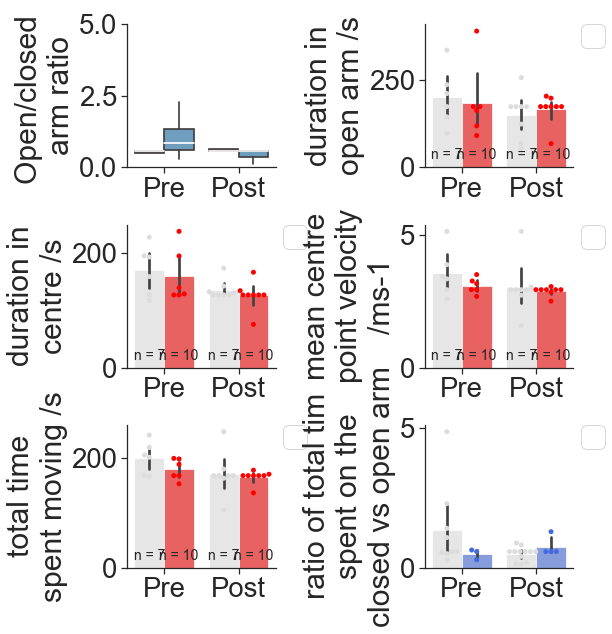

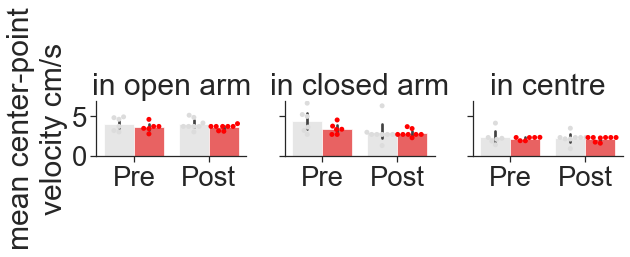

In [209]:
fig = plt.figure(figsize = (8,10))
# n = [6, 8, 6, 8]
sns.set(font_scale=2.5)
sns.set_style("ticks")

ax1 = fig.add_subplot(321)
# category_plotting_2('result','ratio','state_after',maze_data_merge, ax1,['gray', 'tab:red'])

box_colors = {'Agg+': 'tab:red', 'Agg-': 'Tab:blue'}
order = maze_data_merge['state_after'].unique()[::-1]

ax1 = sns.boxplot(x='result', y='ratio', hue='state_after', data = maze_data_merge, palette=box_colors,showfliers=False,
                  medianprops={"color": "w"}, linewidth=1.7, showcaps=False, hue_order=order)
for patch in ax1.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .7))
    
# ax1 = sns.stripplot(x='state_after', y='ratio', data = maze_data_merge, hue='result', jitter=True, 
#               marker='o', size=7, linewidth=1, edgecolor='gray', palette=['gray','tab:red'], alpha=0.5, zorder=0)

# ax = sns.boxplot(x = 'state_after', y = 'contact_latency', data = df_test_p.filter(['contact_latency', 'state_after']).drop_duplicates(), 
#                  whiskerprops=dict(color='tab:red'), medianprops={"color": "w"}, order=['Agg+', 'Agg-'],
#                  boxprops=dict(alpha=0.7,facecolor='tab:red', color='tab:red'), showfliers=False, linewidth=1.7, showcaps=False)

ax1.set(ylabel = 'Open/closed \narm ratio')
ax1.set_xlabel('')
ax1.legend_.remove()
plt.ylim(0,5)
sns.despine()
plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_figure_1/linked figure_supplementary/elevated_plus_maze.pdf',
            dpi=600,bbox_inches='tight', transparent=True)

ax2 = fig.add_subplot(322)
category_plotting_2('result','In open arms open_arm / center-point Cumulative Duration s', 
                    'state_after',maze_data_merge, ax2, ['gainsboro', 'red'])
ax2.set(ylabel = 'duration in\nopen arm /s')
ax2.set_xlabel('')
autolabel_2(ax2, n)

ax3 = fig.add_subplot(323)
category_plotting_2('result','In zone centre / center-point Cumulative Duration s',
                    'state_after',maze_data_merge, ax3, ['gainsboro', 'red'])
ax3.set(ylabel = 'duration in\ncentre /s')
ax3.set_xlabel('')
autolabel_2(ax3, n)

ax4 = fig.add_subplot(324)
category_plotting_2('result','Velocity center-point Mean cm/s',
                    'state_after',maze_data_merge, ax4,['gainsboro', 'red'])
ax4.set(ylabel = 'mean centre\npoint velocity\n/ms-1')
ax4.set_xlabel('')
autolabel_2(ax4, n)

ax5 = fig.add_subplot(325)
category_plotting_2('result','Movement Moving / center-point Cumulative Duration s',
                    'state_after',maze_data_merge, ax5, ['gainsboro', 'red'])
ax5.set(ylabel = 'total time\nspent moving /s')
ax5.set_xlabel('')
autolabel_2(ax5, n)

ax6 = fig.add_subplot(326)
category_plotting_2('result','ratio','state_before',maze_data_merge,ax6,['gainsboro', 'royalblue'])
fig.subplots_adjust(wspace=0.7)
ax6.set(ylabel = 'ratio of total tim\nspent on the\nclosed vs open arm')
ax6.set_xlabel('')
# autolabel_2(ax6, n)

plt.subplots_adjust(hspace=0.4, wspace=1.0)
maze_data_merge_t = maze_data_merge_t.replace(to_replace = 'For center-point in open_arm', value = 'open')
maze_data_merge_t = maze_data_merge_t.replace(to_replace = 'For center-point in closed_arm', value = 'closed')
maze_data_merge_t = maze_data_merge_t.replace(to_replace = 'For center-point in centre', value = 'centre')
g = sns.FacetGrid(maze_data_merge_t, col = 'area_y', legend_out = True)
g.map(sns.swarmplot, 'result_x', 'Velocity center-point Mean cm/s_y','state_after', palette=['gainsboro', 'red'], dodge = True)
g.map(sns.barplot,'result_x', 'Velocity center-point Mean cm/s_y','state_after',alpha=.7, palette=['gainsboro', 'red'])
g.axes[0,0].set_xlabel('')
g.axes[0,0].set_title('in open arm')
g.axes[0,1].set_xlabel('')
g.axes[0,1].set_title('in closed arm')
g.axes[0,2].set_xlabel('')
g.axes[0,2].set_title('in centre')
g.axes[0, 0].set(ylabel = 'mean center-point\nvelocity cm/s');
# g.add_legend()

# Openfield analysis


In [125]:
open_data = pd.read_excel('Statistics-MC_openfield.xlsx', engine = 'openpyxl')
open_data = open_data.loc[open_data['state'].isin(['Pre', 'Post'])]
open_ID = ['BRAC5370.6e', 'BRAC5491.5f', 'BRAC5539.5g', 'BRAC5539.5h',
           'BRAC5539.5i', 'BRAC5626.4e', 'BRAC5626.4f', 'BRAC5626.4g',
           'BRAC5626.4h', 'BRAC5679.4b', 'BRAC5679.4c', 'BRAC5740.4d',
           'BRAC5801.3c', 'BRAC5801.3d', 'BRAC5801.3e', 'BRAC5801.3f',
           'BRAC5858.2g', 'BRAC5370.6e', 'BRAC5491.5f', 'BRAC5539.5g', 
           'BRAC5539.5h', 'BRAC5539.5i', 'BRAC5626.4e', 'BRAC5626.4f',
           'BRAC5626.4g', 'BRAC5626.4h', 'BRAC5679.4b', 'BRAC5679.4c', 
           'BRAC5740.4d', 'BRAC5801.3c', 'BRAC5801.3d', 'BRAC5801.3e', 
           'BRAC5801.3f', 'BRAC5858.2g']

open_data['mice_ID'] = open_ID
open_data_merge = pd.merge(open_data, agg_cond_data_first, how = 'left', on = 'mice_ID')

In [126]:
open_data_merge['ratio'] = open_data_merge['In zone centre / center-point Cumulative Duration s'].div(600)
open_control = open_data_merge[open_data_merge['state'] == 'Pre']
open_test = open_data_merge[open_data_merge['state'] == 'Post']

stats_b, p_b = stats.ttest_ind(open_control[open_control['state_after'] == 'Agg+']['ratio'],
                               open_control[open_control['state_after'] == 'Agg-']['ratio'],
                               equal_var = False)

stats_a, p_a = stats.ttest_ind(open_test[open_test['state_after'] == 'Agg+']['ratio'],
                               open_test[open_test['state_after'] == 'Agg-']['ratio'],
                               equal_var = False)

stats_plus, p_plus = stats.ttest_ind(open_control[open_control['state_after'] == 'Agg+']['ratio'],
                               open_test[open_test['state_after'] == 'Agg+']['ratio'],
                               equal_var = False)

stats_minus, p_minus = stats.ttest_ind(open_control[open_control['state_after'] == 'Agg-']['ratio'],
                               open_test[open_test['state_after'] == 'Agg-']['ratio'],
                               equal_var = False)
print(p_b, p_a, p_plus, p_minus)

0.9841385621824104 0.9484796443263936 0.7365364150422467 0.8744435335032054


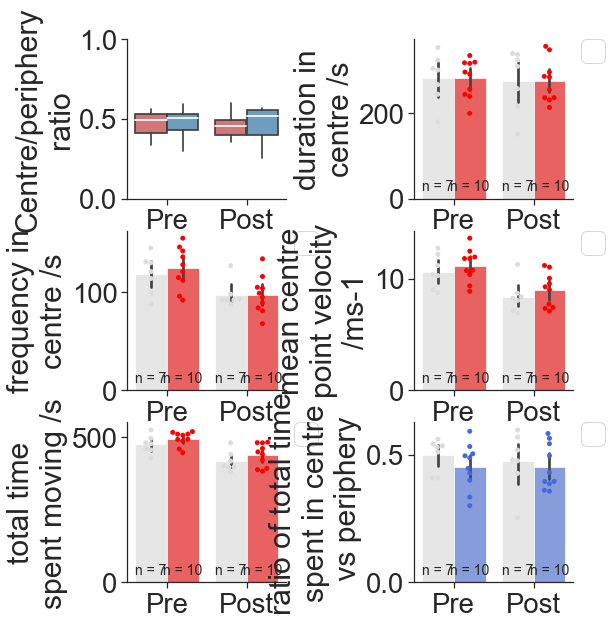

In [208]:
fig = plt.figure(figsize = (8,10))
# n = [7, 7, 10, 10]
sns.set(font_scale=2.5)
sns.set_style("ticks")

ax1 = fig.add_subplot(321)
# category_plotting_2('state','ratio','state_after',open_data_merge, ax1,['gainsboro', 'red'])

# box_colors = {'tab:red', 'Tab:blue','tab:red','Tab:blue'}
box_colors = {'Agg+': 'tab:red', 'Agg-': 'Tab:blue'}
order = open_data_merge['state_after'].unique()[::-1]

ax1 = sns.boxplot(x='state', y='ratio', hue='state_after', data = open_data_merge, showfliers=False,
                  medianprops={"color": "w"}, linewidth=1.7, showcaps=False, palette=box_colors, hue_order=order) #whiskerprops=dict(color=['tab:red', 'tab:blue']

for patch in ax1.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .7))

ax1.set(ylabel = 'Centre/periphery\nratio')
ax1.set_xlabel('')
ax1.legend_.remove()
plt.ylim(0,1)
ax1.yaxis.set_major_locator(plt.MaxNLocator(2))
sns.despine()

# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_figure_1/linked figure_supplementary/openfield.pdf',
#             dpi=600,bbox_inches='tight', transparent=True)

###############################
ax2 = fig.add_subplot(322)
category_plotting_2('state','In zone centre / center-point Cumulative Duration s', 
                    'state_after',open_data_merge, ax2, ['gainsboro', 'red'])
ax2.set(ylabel = 'duration in\ncentre /s')
ax2.set_xlabel('')
autolabel_2(ax2, n)

ax3 = fig.add_subplot(323)
category_plotting_2('state','In zone centre / center-point Frequency',
                    'state_after',open_data_merge, ax3, ['gainsboro', 'red'])
ax3.set(ylabel = 'frequency in\ncentre /s')
ax3.set_xlabel('')
autolabel_2(ax3, n)

ax4 = fig.add_subplot(324)
category_plotting_2('state','Velocity center-point Mean cm/s',
                    'state_after',open_data_merge, ax4,['gainsboro', 'red'])
ax4.set(ylabel = 'mean centre\npoint velocity\n/ms-1')
ax4.set_xlabel('')
autolabel_2(ax4, n)

ax5 = fig.add_subplot(325)
category_plotting_2('state','Movement Moving / center-point Cumulative Duration s',
                    'state_after',open_data_merge, ax5, ['gainsboro', 'red'])
ax5.set(ylabel = 'total time\nspent moving /s')
ax5.set_xlabel('')
autolabel_2(ax5, n)

ax6 = fig.add_subplot(326)
category_plotting_2('state','ratio','state_before',open_data_merge,ax6,['gainsboro', 'royalblue'])
fig.subplots_adjust(wspace=0.8)
ax6.set(ylabel = 'ratio of total time\nspent in centre\n vs periphery')
ax6.set_xlabel('')
autolabel_2(ax6, n)

# Baseline activity examination

baseline data extraction and merging

In [128]:
base_data = pd.read_csv('Statistics-baseline_MC+2.csv')
base_data['mice_ID'] = ID
base_data['moving ratio'] = base_data['Movement Moving / center-point Cumulative Duration'].div(
                            base_data['in Arena Arena / center-point Cumulative Duration'])
base_data_merge = pd.merge(base_data, agg_cond_data_first, how = 'left', on = 'mice_ID')

calculating stats for baseline parameters - comparing pre and post state 

In [129]:
parameters = ['Distance moved center-point Total', 'Velocity center-point Mean', 
              'moving ratio','In centre centre / center-point Cumulative Duration',
              'Distance to zone centre / center-point Mean']

for param in parameters:
    stats_base, p_base = stats.ttest_ind(base_data_merge[maze_data_merge['state_after'] == 'Agg+'][param],
                               base_data_merge[maze_data_merge['state_after'] == 'Agg-'][param],
                               equal_var = False)
    print(param, p_base)

Distance moved center-point Total 0.15241728721814812
Velocity center-point Mean 0.1495017559202885
moving ratio 0.1551939281171604
In centre centre / center-point Cumulative Duration 0.6605170186770086
Distance to zone centre / center-point Mean 0.1829282631796336


visualizing baseline parameters of Agg+ and Agg- groups

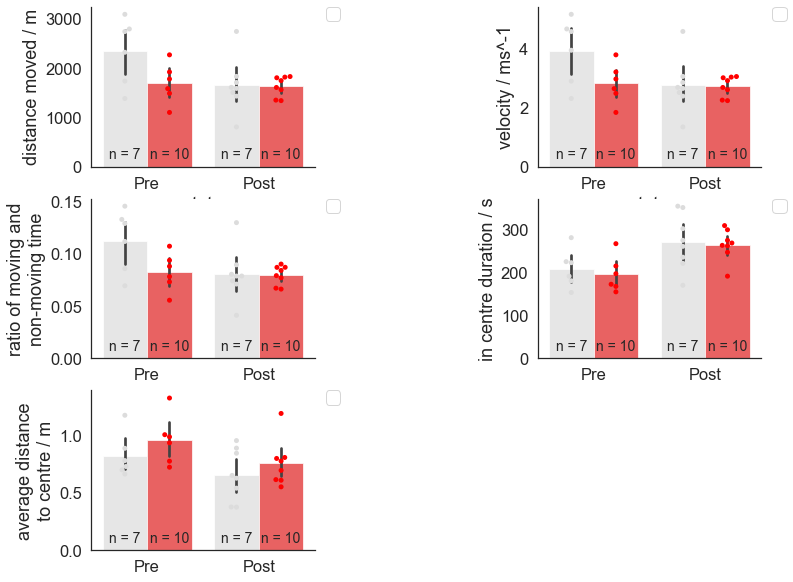

In [130]:
fig = plt.figure(figsize = (12,10))
ax1 = fig.add_subplot(321)
category_plotting_2('state','Distance moved center-point Total',
                    'state_after',base_data_merge, ax1, ['gainsboro', 'red'])
ax1.set(ylabel = 'distance moved / m')
autolabel_2(ax1, n)

ax2 = fig.add_subplot(322)
category_plotting_2('state','Velocity center-point Mean', 
                    'state_after',base_data_merge, ax2, ['gainsboro', 'red'])
ax2.set(ylabel = 'velocity / ms^-1')
autolabel_2(ax2, n)

ax3 = fig.add_subplot(323)
category_plotting_2('state','moving ratio',
                    'state_after',base_data_merge, ax3, ['gainsboro', 'red'])
ax3.set(ylabel = 'ratio of moving and\nnon-moving time')
ax3.set_xlabel('')
autolabel_2(ax3, n)

ax4 = fig.add_subplot(324)
category_plotting_2('state','In centre centre / center-point Cumulative Duration',
                    'state_after',base_data_merge, ax4, ['gainsboro', 'red'])
ax4.set(ylabel = 'in centre duration / s')
ax4.set_xlabel('')
autolabel_2(ax4, n)

ax5 = fig.add_subplot(325)
category_plotting_2('state','Distance to zone centre / center-point Mean',
                    'state_after',base_data_merge, ax5, ['gainsboro', 'red'])
ax5.set(ylabel = 'average distance\nto centre / m')
ax5.set_xlabel('')
autolabel_2(ax5, n)

fig.subplots_adjust(wspace=1.0)
plt.savefig('output_figures/baseline.jpg', dpi = 300, bbox_inch= 'tight')

# Sensitization Analysis

extact proportion of mice turning to be aggressive after different number of pup exposure

In [131]:
dep_data = data[data['exp_cond'] == 'food_deprivation'][data['target'].isin(['pup', 'intruder', 'maze', 'cricket'])]
proportion = {}
ns_time = {}

i = 0
for i in data.exp_time.unique():
    dep_time_data = dep_data[dep_data['exp_time'] == i]
    
    if i > 1:
        dep_time_data = dep_time_data.loc[dep_time_data['prev_exp'].isin(['food_deprivation(4)', 'food_deprivation(5)'])]
        
    agg_time_data = dep_time_data[dep_time_data['state_after'] == 'Agg+'] 
    proportion[str(i)] = len(agg_time_data) / len(dep_time_data)
    ns_time[str(i)] = len(dep_time_data)

print(proportion)
print(ns_time)

{'1': 0.47368421052631576, '2': 0.16666666666666666, '3': 0.045454545454545456, '4': 0.0}
{'1': 76, '2': 30, '3': 22, '4': 18}


plot proportion turning to be aggressive versus times of pup exposure

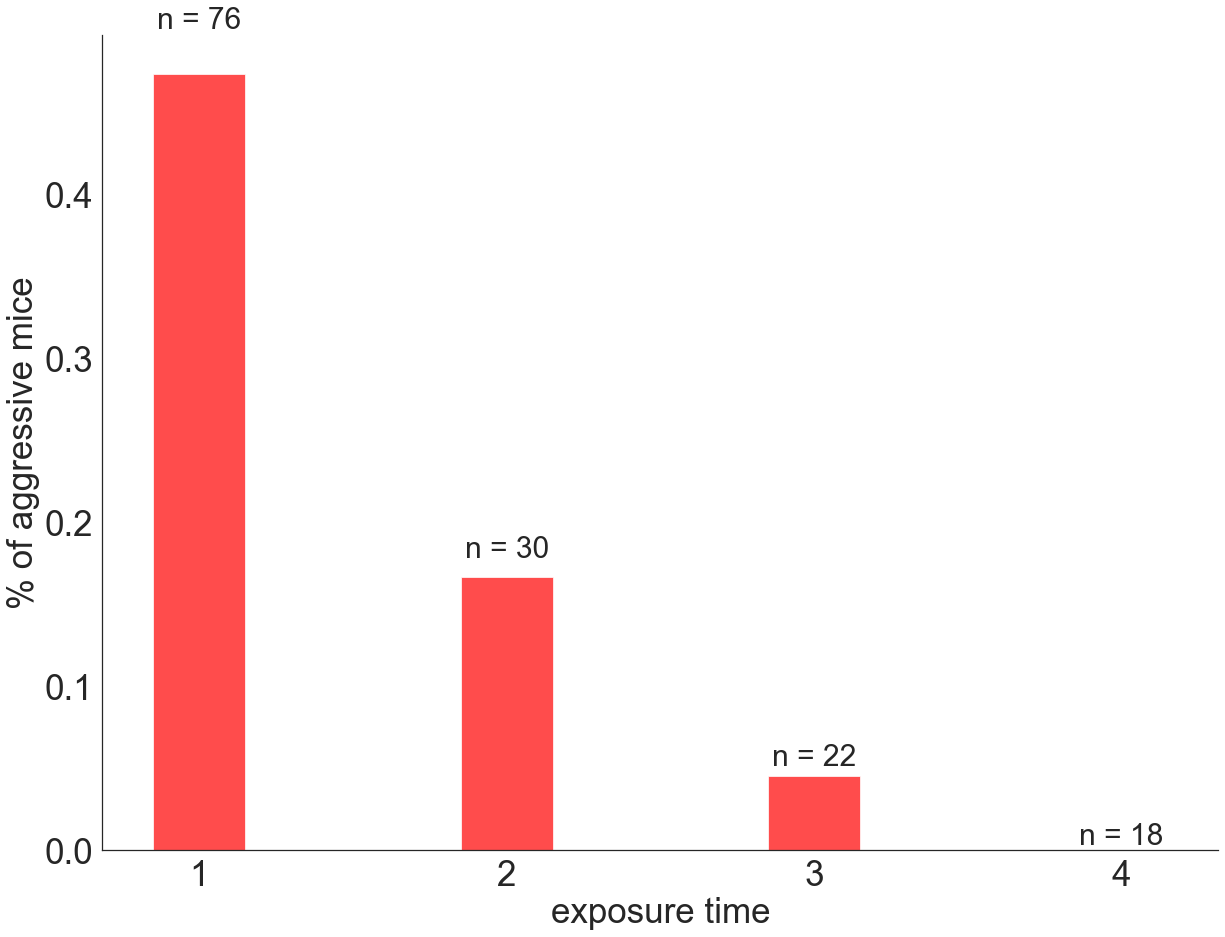

In [132]:
fig , ax = plt.subplots(figsize = (20, 15))
fig = plt.bar(range(len(proportion)), list(proportion.values()),
        tick_label = list(proportion.keys()), align = 'center', 
        color = 'red', width = 0.3, alpha = 0.7)

plt.xlabel('exposure time', fontsize = 35) #, **font
plt.ylabel('% of aggressive mice', fontsize = 35) #, **font
#plt.title('proportion of mice turning to be aggressive\n after different numbers of pup exposure',
#         fontsize = 35, **font, y = 1.08)

i = 0
for position in fig:
    plt.text(position.get_x() + position.get_width()/2., 1.05 * position.get_height(),
            'n = ' + str(list(ns_time.values())[i]) ,ha='center', va='bottom', fontsize = 30)
    i += 1

plt.xticks(fontsize = 35)
plt.yticks(fontsize = 35)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
plt.show()

define dataset containing data of each exposure and extract food intake lines from specified mice groups

In [133]:
lines_1 = []
lines_2 = []
lines_3 = []
ids_1 = []
ids_2 = []
ids_3 = []
food_exp = pd.melt(agg_cond_data,id_vars = ['mice_ID', 'exp_time'], value_vars = ['1h_food_consumption_after']).dropna()

for id in food_exp['mice_ID'].unique():
    if len(food_exp.loc[food_exp['mice_ID'] == id]) > 1 :
        ids_1.append(id)
        lines_1.append(food_exp.loc[food_exp['mice_ID'] == id]['value'][:2].tolist())
        
    if len(food_exp.loc[food_exp['mice_ID'] == id]) > 2:
        ids_2.append(id)
        lines_2.append(food_exp.loc[food_exp['mice_ID'] == id]['value'][1:3].tolist())
        
    if len(food_exp.loc[food_exp['mice_ID'] == id]) > 3:
        ids_3.append(id)
        lines_3.append(food_exp.loc[food_exp['mice_ID'] == id]['value'][2:4].tolist())
        

visualizing individual mouse food intake across 

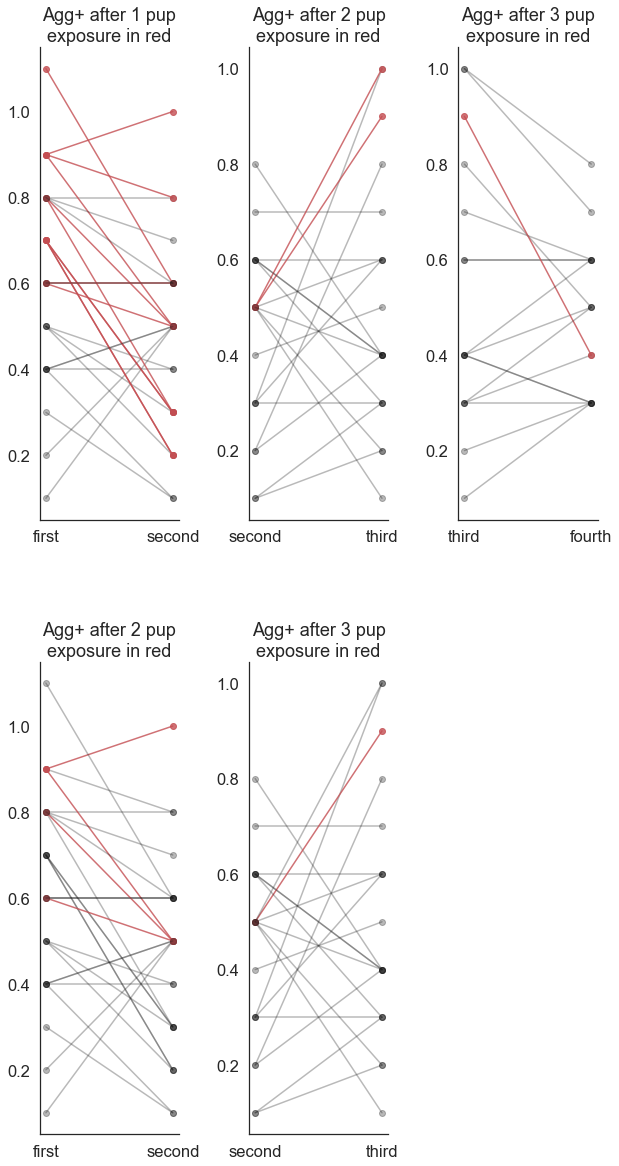

In [134]:
fig = plt.figure(figsize = (10,20))
sns.set(font_scale=1.5)
sns.set_style("white")
ax1 = fig.add_subplot(231) 
x_axis_1 = ['first', 'second']
paired_line(agg_cond_data_first, lines_1,
            'mice_ID', ids_1, 
            'state_after', 'Agg+', 
            x_axis_1)
plt.title('Agg+ after 1 pup\nexposure in red')

ax2 = fig.add_subplot(232) 
x_axis_2 = ['second', 'third']
agg_cond_data_second = agg_cond_data[agg_cond_data['exp_time'] == 2]
paired_line(agg_cond_data_second, lines_2,
            'mice_ID', ids_2, 
            'state_after', 'Agg+', 
            x_axis_2)
plt.title('Agg+ after 2 pup\nexposure in red')

ax3 = fig.add_subplot(233) 
x_axis_3 = ['third', 'fourth']
agg_cond_data_third = agg_cond_data[agg_cond_data['exp_time'] == 3]
paired_line(agg_cond_data_third, lines_3,
            'mice_ID', ids_3, 
            'state_after', 'Agg+', 
            x_axis_3)
plt.title('Agg+ after 3 pup\nexposure in red')

ax4 = fig.add_subplot(234) 

#paired_line(agg_cond_data_first, lines_1,
#            'mice_ID', ids_1, 
#            'state_after', 'Agg+', 
#            x_axis_1, colour = 'blue')
#plt.title('Agg+ when exp_time = 1')

paired_line(agg_cond_data_second, lines_1,
            'mice_ID', ids_1, 
            'state_after', 'Agg+', 
            x_axis_1)
plt.title('Agg+ after 2 pup\nexposure in red')

ax5 = fig.add_subplot(235) 
paired_line(agg_cond_data_third, lines_2,
            'mice_ID', ids_2, 
            'state_after', 'Agg+', 
            x_axis_2)
plt.title('Agg+ after 3 pup\nexposure in red')
fig.subplots_adjust(wspace=0.5, hspace = 0.3)

In [135]:
id_data = agg_cond_data_first[agg_cond_data_first['mice_ID'].isin(ids_1)].reset_index()
id_data_sec = agg_cond_data_second[agg_cond_data_second['mice_ID'].isin(ids_1)].reset_index()
id_data['intake_per_change'] = (id_data_sec['1h_food_consumption_after'] - id_data['1h_food_consumption_after']) / id_data['1h_food_consumption_after']
id_agg_first = [x for x in ids_1 if x not in ids_2]
id_agg_data_first = id_data[id_data['mice_ID'].isin(id_agg_first)]

stat_exp_fd, p_exp_fd = stats.ttest_ind(id_data[id_data['state_after'] =='Agg-']['intake_per_change'],
                                        id_data[id_data['state_after'] =='Agg+']['intake_per_change'],
                                        equal_var = False)
print(p_exp_fd)

0.06268883011202976


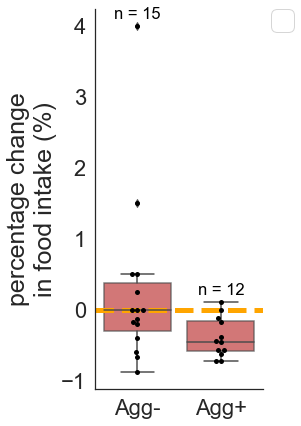

In [136]:
sns.set(rc={'figure.figsize':(3,7)})
sns.set(font_scale=2)
sns.set_style("white")
ax = category_plotting('state_after','intake_per_change', None, id_data, None)

#autolabel_2(ax, food_intake_n)
plt.axhline(0, linestyle = 'dashed', linewidth=5, color='orange')
plt.xlabel(None)
plt.ylabel('percentage change\nin food intake (%)', fontsize=25)

nobs = ["n = " + str(i) for i in (len(id_data[id_data['state_after'] =='Agg-']), 
                                  len(id_data[id_data['state_after'] =='Agg+']))]
sens_max = [id_data[id_data['state_after'] == state]['intake_per_change'].max() for state in ['Agg-', 'Agg+']]

pos = range(len(nobs))
for tick,label in zip(pos,ax.get_xticklabels()):
    ax.text(pos[tick],
            sens_max[tick] + 0.1,
            nobs[tick],
            horizontalalignment='center',
            size='x-small',
            color='black')

how food intake change as pup exposure time increase

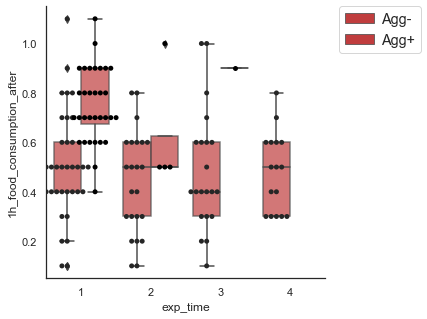

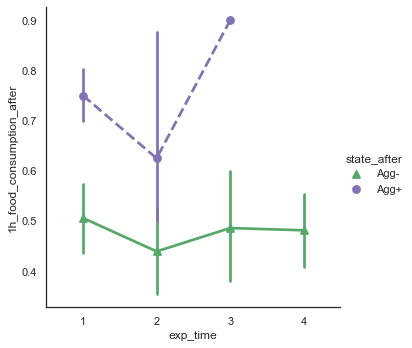

In [137]:
sns.set(rc={'figure.figsize':(5,5)})
sns.set_style("white")
category_plotting('exp_time','1h_food_consumption_after',
                  'state_after',agg_cond_data,
                  [1,2,3,4])
sns.catplot(x="exp_time", y="1h_food_consumption_after", hue="state_after",
            palette={"Agg-": "g", "Agg+": "m"},
            markers=["^", "o"], linestyles=["-", "--"],
            kind="point", data=agg_cond_data)

# Refeeding Experiment

import data from refeeding experiment

In [138]:
refeeding_dat = pd.read_csv('NPW_refeeding.csv')
ob_per = refeeding_dat.groupby(['state','object_state']).size().reset_index(name = 'n')
fd_per = refeeding_dat.groupby(['state', 'food_state']).size().reset_index(name = 'n')
ob_per['count'] = ob_per['n'].sum()
ob_per['percentage'] = ob_per['n'] / ob_per['count'] *100
ob_per = ob_per.replace('refeeding_1h', 'object in')
ob_per = ob_per.rename(columns = {'object_state': 'refeeding_state'})
fd_per['count'] = fd_per['n'].sum()
fd_per['percentage'] = fd_per['n'] / fd_per['count'] *100
fd_per = fd_per.replace('refeeding_1h', 'food in')
fd_per = fd_per.rename(columns = {'food_state': 'refeeding_state'})

refeeding_plot = pd.concat([ob_per, fd_per])
refeeding_plot = refeeding_plot[refeeding_plot['refeeding_state'] == 'Agg+']
print(refeeding_plot)

       state refeeding_state  n  count  percentage
0  object in            Agg+  5      6   83.333333
0    food in            Agg+  1      8   12.500000


In [139]:
stat, p, dof, expected  = stats.chi2_contingency([[10, 0],
                                                  [3 , 7]])

print(p)

0.004910556162172649


In [140]:
# refeeding_plot

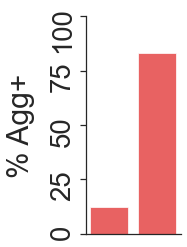

In [141]:
sns.set(rc={"figure.figsize": (1.7, 4)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

g = sns.barplot(x = 'state',
                y = 'percentage',
                data = refeeding_plot, order = ['food in', 'object in'],
                alpha = 0.7, palette = ['red']
               )


plt.ylabel('% Agg+', labelpad=15)
plt.xlabel('')
plt.xticks([])
plt.yticks(rotation=90)
plt.locator_params(axis='y', nbins=4)
plt.ylim(0,100)
sns.despine()

# i = 0
# for p in g.patches:
#     g.annotate('n = '+ str(refeeding_plot['count'].tolist()[i]), (p.get_x() + p.get_width() / 2., p.get_height()), 
#                 ha='center', va='center', xytext=(0, 12), 
#                 textcoords='offset points', fontsize = 18)
#     i = i+1
# 
plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Figure_1/linked_figure1/competition.pdf',bbox_inches='tight')